# Pipeline Data Science: Bike Sharing Demand và Telco Churn

## Bài toán 1: Bike Sharing Demand

- **Loại bài toán:** hồi quy theo thời gian.
- **Đơn vị quan sát:** một dòng tương ứng với một giờ vận hành của hệ thống thuê xe.
- **Target:** `cnt`, tổng số lượt thuê xe trong giờ đó.
- **Ý nghĩa kinh doanh:** dự báo nhu cầu theo giờ để hỗ trợ điều phối xe, chuẩn bị tồn xe, phát hiện giờ cao điểm và hiểu ảnh hưởng của lịch/thời tiết tới nhu cầu.

## Bài toán 2: Telco Customer Churn

- **Loại bài toán:** phân loại nhị phân.
- **Đơn vị quan sát:** một dòng tương ứng với một khách hàng Telco.
- **Target:** `Churn`, trong đó `Yes` là khách hàng đã rời dịch vụ.
- **Ý nghĩa kinh doanh:** xếp hạng rủi ro churn để ưu tiên chăm sóc, tối ưu chiến dịch giữ chân khách hàng và cân bằng giữa bắt đúng churn với chi phí liên hệ nhầm.


## 0. Thiết lập môi trường và import thư viện

Cell setup chuẩn bị toàn bộ thư viện cần cho notebook chạy trên Colab. Phần `%pip install` cài các package bên ngoài môi trường Python mặc định, gồm:

- `kagglehub`: tải dataset trực tiếp từ Kaggle.
- `pandas`, `numpy`: xử lý bảng dữ liệu và tính toán số.
- `matplotlib`, `seaborn`: trực quan hóa EDA và evaluation.
- `scikit-learn`: preprocessing, model, cross-validation, metric và model inspection.
- `scipy`: cung cấp phân phối `loguniform` cho random search hyperparameter.
- `joblib`: thường được scikit-learn dùng cho parallelism/model persistence; trong notebook này chủ yếu đảm bảo môi trường đầy đủ.

Sau đó cell import các module dùng xuyên suốt. Một vài config:

- `RANDOM_STATE = 42` giúp kết quả tái lập khi random split hoặc random search.
- `np.random.seed(RANDOM_STATE)` cố định seed phía NumPy.
- `pd.set_option(...)` giúp bảng hiển thị nhiều cột và số dạng dễ đọc.
- `sns.set_theme(...)` thống nhất style biểu đồ.



In [14]:
%pip install -q kagglehub pandas numpy matplotlib seaborn scikit-learn scipy joblib

In [15]:
import inspect
from pathlib import Path
import warnings

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import loguniform
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    TimeSeriesSplit,
    cross_val_predict,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 140)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')

### 0.1. Các hàm tiện ích dùng chung


## Nhóm hàm tải và kiểm tra dữ liệu

- `download_dataset(slug)`: tải dataset từ Kaggle bằng KaggleHub, in đường dẫn cache và các file CSV tìm được. Output của hàm này giúp xác nhận notebook đang đọc đúng dataset.
- `find_csv(root, preferred_name=None)`: tìm file CSV mong muốn trong thư mục đã tải. Nếu có nhiều file, tham số `preferred_name` giúp chọn đúng file như `hour.csv` hoặc file Telco chính.
- `show_missing(df)`: trả về bảng `missing_count` và `missing_rate` theo từng cột. Bảng này dùng trong EDA để quyết định cột nào cần impute, drop hoặc xử lý đặc biệt.

## Nhóm hàm preprocessing/model compatibility

- `make_ohe()`: tạo `OneHotEncoder` tương thích nhiều phiên bản scikit-learn. Các version mới dùng `sparse_output=False`, version cũ dùng `sparse=False`.
- `estimator_supports_parameter(estimator, parameter_name)`: kiểm tra model hiện tại có tham số nào đó không. Notebook dùng hàm này để chỉ thêm `class_weight` vào `HistGradientBoostingClassifier` khi môi trường scikit-learn hỗ trợ.

## Nhóm hàm metric

- `regression_metrics(y_true, y_pred)`: tính MAE, RMSE và R2 cho Bike.
- `classification_metrics(y_true, y_score, threshold)`: chuyển score thành nhãn bằng threshold rồi tính accuracy, precision, recall, F1, ROC-AUC và PR-AUC cho Telco.
- `positive_expm1(x)`: inverse transform an toàn cho mô hình log-target, đảm bảo dự báo sau `expm1` không âm.

## Nhóm hàm giải thích mô hình

- `plot_perm_importance(...)`: đo permutation importance. Ý tưởng là hoán vị từng feature trên test set, dự báo lại, rồi đo metric xấu đi bao nhiêu. Nếu hoán vị một feature làm metric giảm mạnh, feature đó đang mang nhiều thông tin cho mô hình.


In [16]:
def download_dataset(slug):
    path = Path(kagglehub.dataset_download(slug))
    print(f'Downloaded {slug} -> {path}')
    for file in sorted(path.rglob('*.csv')):
        print(' -', file.name)
    return path


def find_csv(root, preferred_name=None):
    files = sorted(Path(root).rglob('*.csv'))
    if preferred_name:
        for file in files:
            if file.name.lower() == preferred_name.lower():
                return file
    if not files:
        raise FileNotFoundError(f'No csv under {root}')
    return files[0]


def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def show_missing(df):
    return (
        df.isna().sum().to_frame('missing_count')
        .assign(missing_rate=lambda x: x['missing_count'] / len(df))
        .sort_values(['missing_count', 'missing_rate'], ascending=False)
    )


def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }


def positive_expm1(x):
    return np.maximum(0, np.expm1(x))


def classification_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }


def estimator_supports_parameter(estimator, parameter_name):
    return parameter_name in estimator.get_params(deep=False)


def plot_perm_importance(model, X, y, scoring, title, top_n=15):
    result = permutation_importance(
        model,
        X,
        y,
        scoring=scoring,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    imp = (
        pd.DataFrame({'feature': X.columns, 'importance': result.importances_mean})
        .sort_values('importance', ascending=False)
        .head(top_n)
    )
    display(imp)
    plt.figure(figsize=(9, 6))
    sns.barplot(data=imp, x='importance', y='feature', color='#4C78A8')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return imp

# 1. Bike Sharing Demand Forecasting

## 1.1. Tải dữ liệu và kiểm tra cấu trúc ban đầu

Cell này thực hiện các việc sau:

1. Tải dataset Kaggle `lakshmi25npathi/bike-sharing-dataset`.
2. Chọn file `hour.csv`, vì bài toán đang dự báo nhu cầu theo từng giờ.
3. Đọc CSV vào `bike_df`.
4. Chuyển `dteday` sang kiểu `datetime64` để có thể sort theo thời gian và vẽ trend.
5. In `shape`, hiển thị vài dòng đầu và gọi `info()`.


In [17]:
bike_root = download_dataset('lakshmi25npathi/bike-sharing-dataset')
bike_csv = find_csv(bike_root, 'hour.csv')
print('Using:', bike_csv)

bike_df = pd.read_csv(bike_csv)
bike_df['dteday'] = pd.to_datetime(bike_df['dteday'])
print('Shape:', bike_df.shape)
display(bike_df.head())
bike_df.info()

Downloaded lakshmi25npathi/bike-sharing-dataset -> /kaggle/input/bike-sharing-dataset
 - day.csv
 - hour.csv
Using: /kaggle/input/bike-sharing-dataset/hour.csv
Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.2400,0.2879,0.8100,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.2200,0.2727,0.8000,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.2200,0.2727,0.8000,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.2400,0.2879,0.7500,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.2400,0.2879,0.7500,0.0000,0,1,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

- `Shape: (17379, 17)` nghĩa là dữ liệu có 17,379 quan sát theo giờ và 17 cột ban đầu.
- `head()` cho thấy các cột lịch (`season`, `yr`, `mnth`, `hr`, `weekday`), thời tiết (`temp`, `hum`, `windspeed`) và target (`cnt`).
- `info()` xác nhận không có missing ở dữ liệu Bike gốc và `dteday` đã là datetime.
- `casual` và `registered` cộng lại thành `cnt`; hai cột này rất dễ gây target leakage nếu đưa vào feature, nên sẽ bị loại ở bước modeling.

## 1.2. EDA Bike Sharing

Mục tiêu của EDA Bike là hiểu **cơ chế tạo ra nhu cầu thuê xe theo giờ** trước khi đưa dữ liệu vào mô hình. Với bài toán này, EDA không chỉ để vẽ đẹp; nó quyết định trực tiếp cách tạo feature và cách chia validation.

Các câu hỏi cần trả lời:

1. `cnt` có phân phối cân bằng hay lệch phải mạnh?
2. Nhu cầu có lặp lại theo giờ, ngày trong tuần, mùa hoặc thời tiết không?
3. Có những giờ nhu cầu cực cao cần mô hình học tốt không?
4. Biến nào có nguy cơ gây leakage nếu đưa vào mô hình?

Cell EDA tạo ra các bảng và biểu đồ sau:

- `Rows, columns`: xác nhận kích thước dataset.
- `Duplicate rows`: kiểm tra dòng trùng.
- `describe(include='all')`: xem min, max, mean, median, percentiles của từng cột.
- `show_missing(bike_df)`: kiểm tra missing value.
- `target_stats`: so sánh `cnt` và `log1p(cnt)` để xem target có cần biến đổi log không.
- Bảng top 1% demand: xem các giờ có nhu cầu cao nhất rơi vào bối cảnh nào.


Rows, columns: (17379, 17)
Duplicate rows: 0


,count,mean,min,25%,50%,75%,max,std
instant,"17,379.0000","8,690.0000",1.0000,"4,345.5000","8,690.0000","13,034.5000","17,379.0000","5,017.0295"
dteday,17379,2012-01-02 04:08:34.552045568,2011-01-01 00:00:00,2011-07-04 00:00:00,2012-01-02 00:00:00,2012-07-02 00:00:00,2012-12-31 00:00:00,NaN
season,"17,379.0000",2.5016,1.0000,2.0000,3.0000,3.0000,4.0000,1.1069
yr,"17,379.0000",0.5026,0.0000,0.0000,1.0000,1.0000,1.0000,0.5000
mnth,"17,379.0000",6.5378,1.0000,4.0000,7.0000,10.0000,12.0000,3.4388
hr,"17,379.0000",11.5468,0.0000,6.0000,12.0000,18.0000,23.0000,6.9144
holiday,"17,379.0000",0.0288,0.0000,0.0000,0.0000,0.0000,1.0000,0.1672
weekday,"17,379.0000",3.0037,0.0000,1.0000,3.0000,5.0000,6.0000,2.0058
workingday,"17,379.0000",0.6827,0.0000,0.0000,1.0000,1.0000,1.0000,0.4654
weathersit,"17,379.0000",1.4253,1.0000,1.0000,1.0000,2.0000,4.0000,0.6394


,missing_count,missing_rate
instant,0,0.0000
dteday,0,0.0000
season,0,0.0000
yr,0,0.0000
mnth,0,0.0000
hr,0,0.0000
holiday,0,0.0000
weekday,0,0.0000
workingday,0,0.0000
weathersit,0,0.0000


,count,mean,std,min,25%,50%,75%,max,skew
cnt,"17,379.0000",189.4631,181.3876,1.0000,40.0000,142.0000,281.0000,977.0000,1.2774
log1p_cnt,"17,379.0000",4.5747,1.4179,0.6931,3.7136,4.9628,5.6419,6.8855,-0.8182


Peak-demand threshold (top 1% cnt): 782.2200000000012


,dteday,season,mnth,hr,weekday,workingday,weathersit,temp,hum,windspeed,cnt
14773,2012-09-12,3,9,18,3,1,1,0.6600,0.4400,0.2537,977
14964,2012-09-20,3,9,17,4,1,1,0.6400,0.5000,0.2239,976
14748,2012-09-11,3,9,17,2,1,1,0.7000,0.2800,0.0000,970
14725,2012-09-10,3,9,18,1,1,1,0.6200,0.3500,0.2985,968
15084,2012-09-25,4,9,17,2,1,1,0.6600,0.3900,0.2836,967
15780,2012-10-24,4,10,17,3,1,1,0.6600,0.4700,0.0000,963
10622,2012-03-23,2,3,17,5,1,2,0.7200,0.4200,0.1642,957
15108,2012-09-26,4,9,17,3,1,1,0.7400,0.4800,0.2985,953
15444,2012-10-10,4,10,17,3,1,1,0.5800,0.4300,0.2239,948
15588,2012-10-16,4,10,17,2,1,1,0.5200,0.3900,0.1940,943


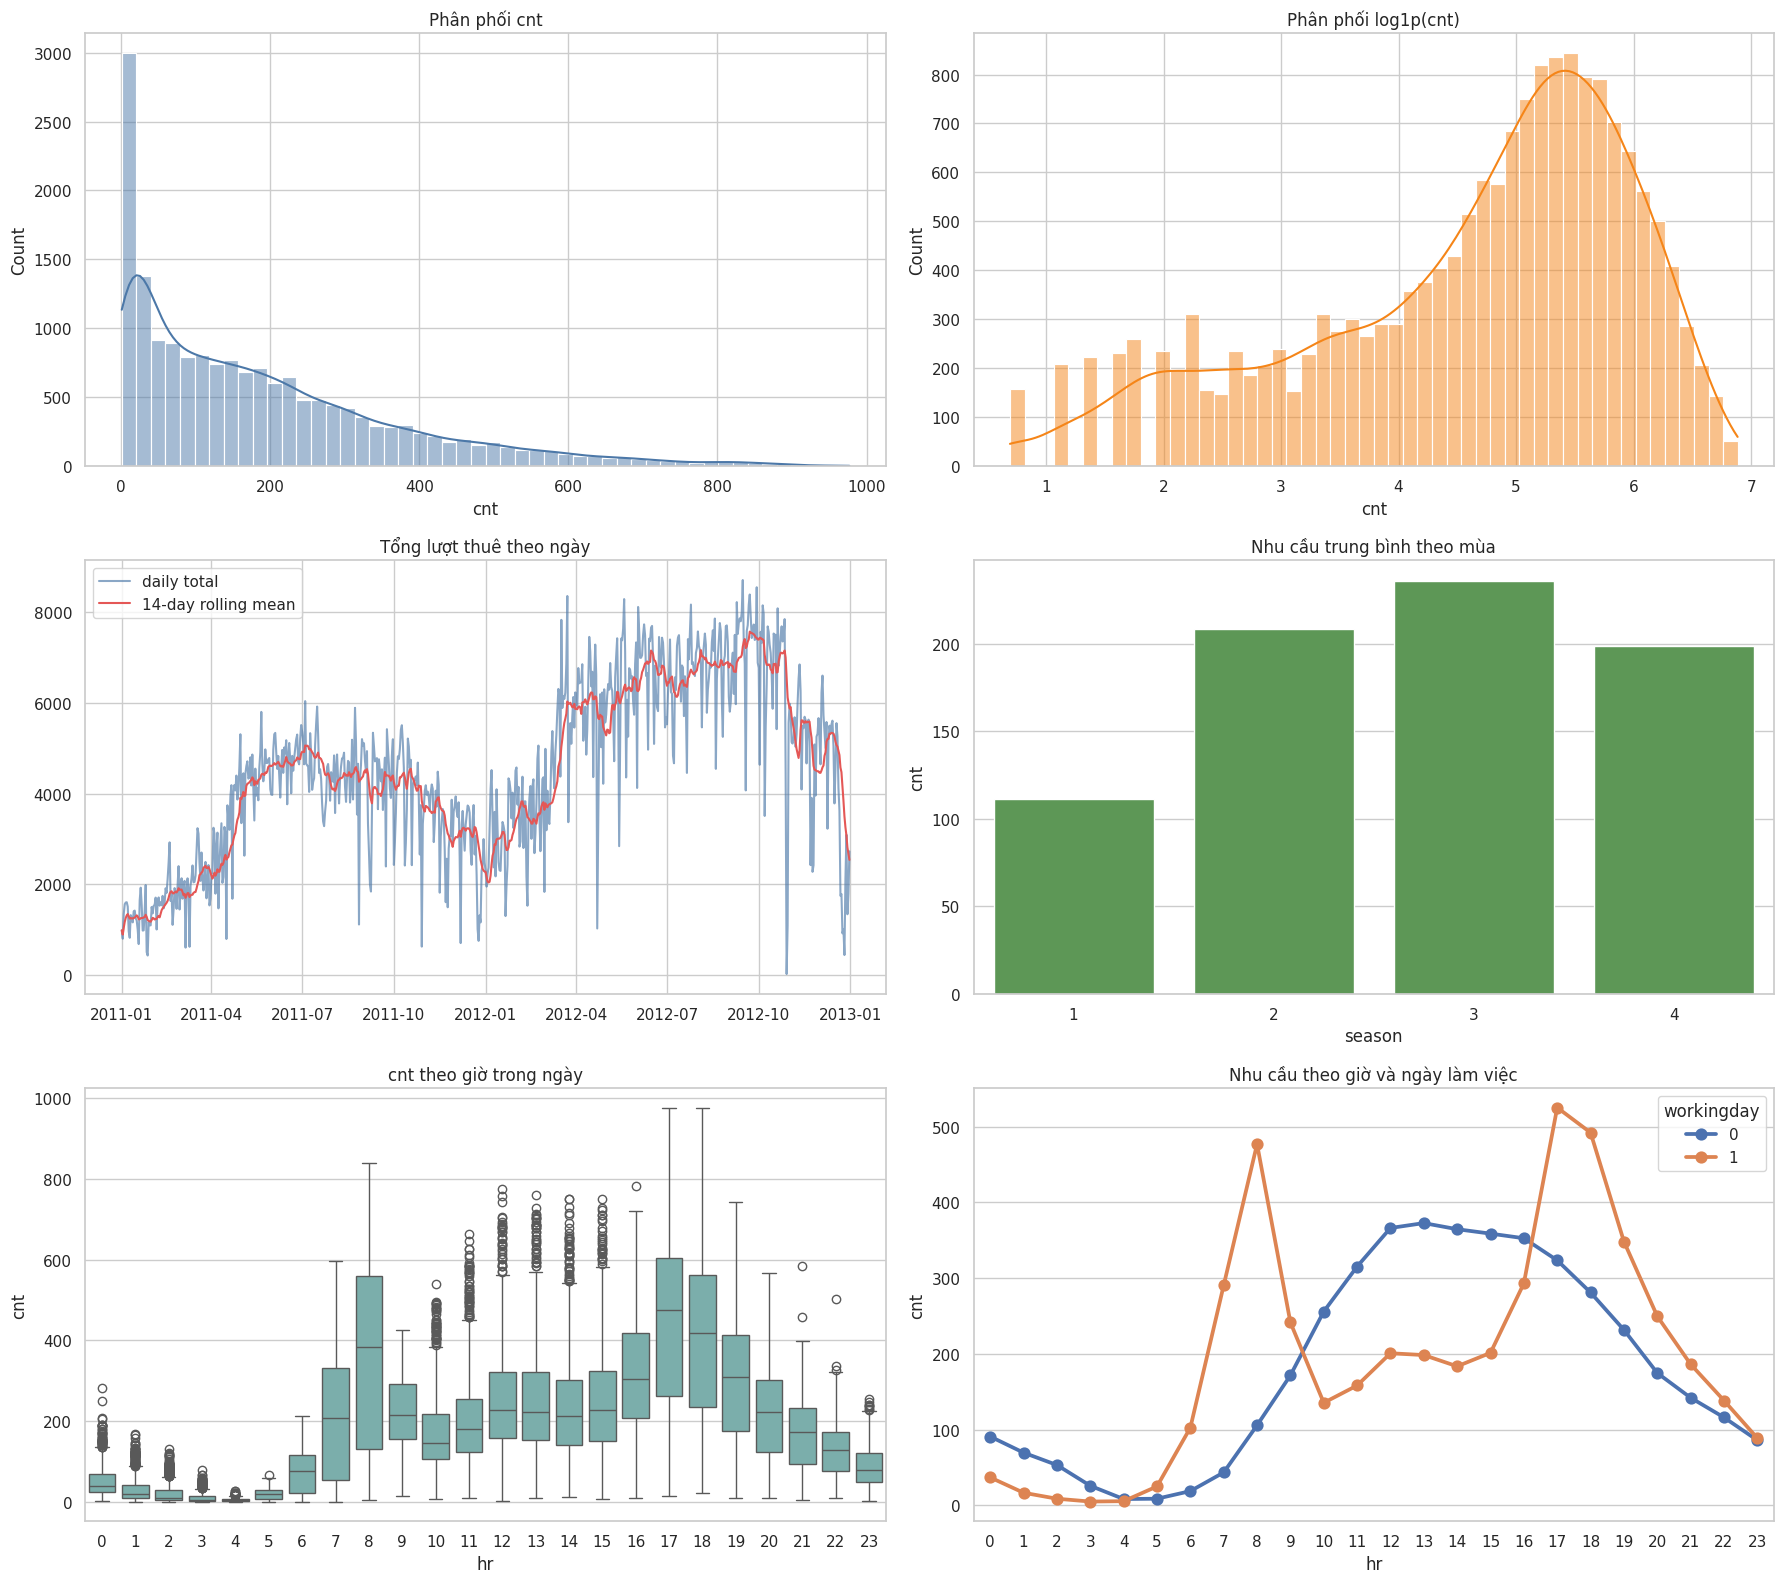

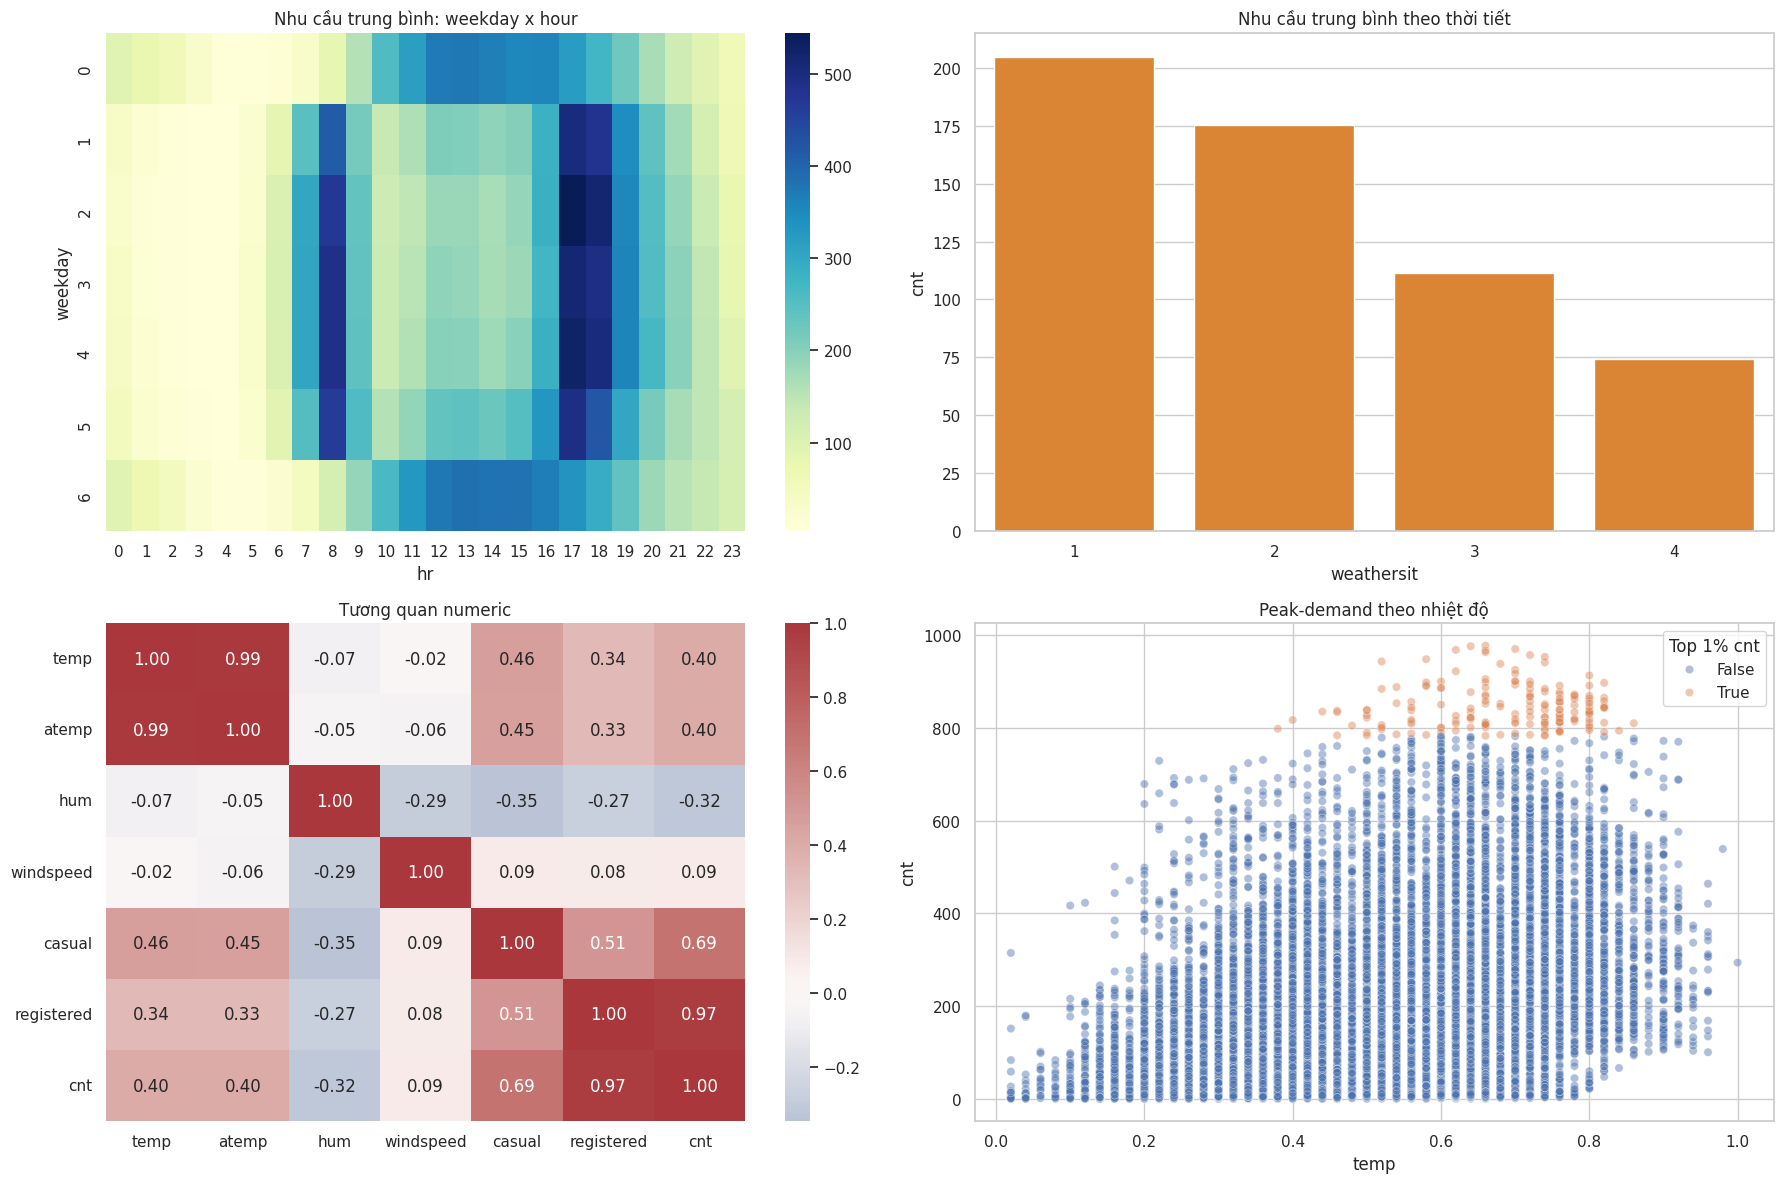

In [5]:
print('Rows, columns:', bike_df.shape)
print('Duplicate rows:', bike_df.duplicated().sum())
display(bike_df.describe(include='all').T)
display(show_missing(bike_df))

target_stats = pd.DataFrame({
    'cnt': bike_df['cnt'].describe(),
    'log1p_cnt': np.log1p(bike_df['cnt']).describe(),
}).T
target_stats['skew'] = [bike_df['cnt'].skew(), np.log1p(bike_df['cnt']).skew()]
display(target_stats)

bike_daily = bike_df.groupby('dteday', as_index=False)['cnt'].sum()
bike_monthly = bike_df.groupby(['yr', 'mnth'], as_index=False)['cnt'].sum()
bike_monthly['year_month'] = bike_monthly['yr'].astype(str) + '-' + bike_monthly['mnth'].astype(str).str.zfill(2)
bike_peak_threshold = bike_df['cnt'].quantile(0.99)
bike_peaks = bike_df.loc[bike_df['cnt'] >= bike_peak_threshold, ['dteday', 'season', 'mnth', 'hr', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'cnt']]
print('Peak-demand threshold (top 1% cnt):', bike_peak_threshold)
display(bike_peaks.sort_values('cnt', ascending=False).head(15))

fig, ax = plt.subplots(3, 2, figsize=(18, 16))
sns.histplot(bike_df['cnt'], bins=50, kde=True, ax=ax[0, 0], color='#4C78A8')
ax[0, 0].set_title('Phân phối cnt')
sns.histplot(np.log1p(bike_df['cnt']), bins=50, kde=True, ax=ax[0, 1], color='#F58518')
ax[0, 1].set_title('Phân phối log1p(cnt)')

ax[1, 0].plot(bike_daily['dteday'], bike_daily['cnt'], color='#4C78A8', alpha=0.65, label='daily total')
ax[1, 0].plot(bike_daily['dteday'], bike_daily['cnt'].rolling(14, min_periods=1).mean(), color='#E45756', label='14-day rolling mean')
ax[1, 0].set_title('Tổng lượt thuê theo ngày')
ax[1, 0].legend()
sns.barplot(data=bike_df, x='season', y='cnt', estimator=np.mean, errorbar=None, ax=ax[1, 1], color='#54A24B')
ax[1, 1].set_title('Nhu cầu trung bình theo mùa')

sns.boxplot(data=bike_df, x='hr', y='cnt', ax=ax[2, 0], color='#72B7B2')
ax[2, 0].set_title('cnt theo giờ trong ngày')
sns.pointplot(data=bike_df, x='hr', y='cnt', hue='workingday', errorbar=None, ax=ax[2, 1])
ax[2, 1].set_title('Nhu cầu theo giờ và ngày làm việc')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 2, figsize=(18, 12))
hour_weekday = bike_df.pivot_table(index='weekday', columns='hr', values='cnt', aggfunc='mean')
sns.heatmap(hour_weekday, cmap='YlGnBu', ax=ax[0, 0])
ax[0, 0].set_title('Nhu cầu trung bình: weekday x hour')

weather_rate = bike_df.groupby('weathersit', as_index=False)['cnt'].mean()
sns.barplot(data=weather_rate, x='weathersit', y='cnt', ax=ax[0, 1], color='#F58518')
ax[0, 1].set_title('Nhu cầu trung bình theo thời tiết')

bike_corr_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
sns.heatmap(bike_df[bike_corr_cols].corr(), annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax[1, 0])
ax[1, 0].set_title('Tương quan numeric')

sns.scatterplot(data=bike_df, x='temp', y='cnt', hue=bike_df['cnt'] >= bike_peak_threshold, alpha=0.45, ax=ax[1, 1])
ax[1, 1].set_title('Peak-demand theo nhiệt độ')
ax[1, 1].legend(title='Top 1% cnt')
plt.tight_layout()
plt.show()

### Phân tích EDA Bike

Dữ liệu Bike có `17,379` dòng, `17` cột, không có duplicate và không có missing. Đây là dataset sạch ở mức bảng thô, nên trọng tâm không phải xử lý lỗi dữ liệu mà là **hiểu pattern demand** và **tránh leakage**.

## 1. Phân phối target `cnt`

`cnt` có mean khoảng `189.46`, median `142`, max `977`, skew khoảng `1.2774`. Mean lớn hơn median và skew dương cho thấy phân phối lệch phải: rất nhiều giờ có demand thấp/trung bình, nhưng có một số giờ demand cực cao.

Ý nghĩa:

- Model không thể chỉ tối ưu tốt ở giờ bình thường; các giờ peak sẽ làm RMSE tăng mạnh.
- MAE và RMSE cần đọc cùng nhau. RMSE cao hơn MAE nhiều thường báo hiệu có lỗi lớn ở peak demand.
- Việc thử `log1p(cnt)` là hợp lý vì log giúp giảm ảnh hưởng của giá trị quá lớn.

Sau `log1p`, skew giảm xuống khoảng `-0.8182`. Điều này không tự động chứng minh log-target tốt hơn, nhưng đủ để đưa biến thể log-target vào benchmark. Kết quả modeling phía sau cho thấy log-target không thắng HGB trực tiếp trên `cnt`, nhưng quyết định thử là có cơ sở từ EDA.

## 2. Bảng top 1% demand

Ngưỡng top 1% demand là khoảng `782.22`. Các dòng cao nhất chủ yếu rơi vào giờ `17-18`, ngày làm việc, nhiều ở tháng 9-10 và thời tiết tốt hoặc tương đối tốt.

Ý nghĩa:

- Peak demand không xuất hiện ngẫu nhiên; nó gắn với giờ đi làm/đi về và mùa cụ thể.
- Feature `rush_hour`, `workingday`, `rush_hour_workingday`, `mnth`, `season` là cần thiết.
- Nếu triển khai thật, peak demand là nhóm cần ưu tiên vì thiếu xe vào giờ peak gây ảnh hưởng vận hành lớn hơn sai số ở giờ thấp điểm.

## 3. Histogram `cnt` và `log1p(cnt)`

Histogram `cnt` cho thấy đa số quan sát nằm ở vùng demand thấp đến trung bình, kèm đuôi phải dài. Histogram `log1p(cnt)` làm đuôi phải ngắn lại và phân phối dễ học hơn về mặt thống kê.

Kết luận từ hai biểu đồ này:

- Target không phân phối chuẩn.
- Nên dùng model phi tuyến/tree-based thay vì chỉ dựa vào mô hình tuyến tính đơn giản.
- Nên báo cáo RMSE vì peak quan trọng, nhưng cũng cần MAE để hiểu sai số trung bình dễ diễn giải.

## 4. Trend daily demand và rolling mean 14 ngày

Đường daily demand dao động mạnh theo ngày, còn rolling mean 14 ngày làm rõ xu hướng dài hơn. Khi đường rolling thay đổi theo thời gian, ta thấy demand chịu ảnh hưởng của mùa và giai đoạn năm, không chỉ giờ trong ngày.

Ý nghĩa:

- Dữ liệu có yếu tố thời gian rõ, nên random split sẽ làm đánh giá quá lạc quan.
- Cần dùng time-based split và `TimeSeriesSplit`.
- Các feature tháng/năm/mùa và mã hóa chu kỳ tháng là có ý nghĩa.

## 5. Nhu cầu trung bình theo mùa

Barplot theo `season` cho thấy demand thay đổi theo mùa. Mùa lạnh/thời tiết kém thường có nhu cầu thấp hơn, còn các mùa dễ di chuyển bằng xe đạp có nhu cầu cao hơn.

Ý nghĩa:

- `season` không chỉ là biến mô tả, mà là tín hiệu dự báo.
- Mô hình cần học interaction giữa mùa và thời tiết/nhiệt độ.
- Nếu dùng mô hình tuyến tính, nên tạo interaction thủ công; với tree/boosting, mô hình có thể học interaction tốt hơn.

## 6. Boxplot `cnt` theo giờ

Boxplot theo `hr` cho thấy demand rất khác nhau theo giờ. Các giờ khuya/sáng sớm thường thấp; giờ đi làm và tan làm có median và outlier cao hơn.

Ý nghĩa:

- `hr` là một trong những feature quan trọng nhất.
- `rush_hour` không phải feature tùy ý; nó được EDA chứng minh.
- Vì giờ là chu kỳ 24h, thêm `hr_sin` và `hr_cos` giúp mô hình hiểu 23h gần 0h.

## 7. Pointplot theo giờ và ngày làm việc

Pointplot `hr` theo `workingday` cho thấy pattern ngày làm việc và không làm việc khác nhau. Ngày làm việc thường có hai đỉnh rõ vào sáng và chiều; ngày không làm việc thường dàn đều hơn ở giữa ngày.

Ý nghĩa:

- Không nên chỉ dùng riêng `hr` hoặc riêng `workingday`.
- Interaction `rush_hour_workingday` giúp mô hình học đúng hành vi commute.
- Đây cũng là lý do feature importance phía sau có `rush_hour_workingday` đứng cao.

## 8. Heatmap `weekday x hour`

Heatmap cho thấy demand là một bề mặt hai chiều theo ngày trong tuần và giờ. Vùng màu đậm ở một số tổ hợp ngày-giờ xác nhận tính chu kỳ theo lịch.

Ý nghĩa:

- Pattern demand không giống nhau ở mọi ngày.
- Feature `weekday`, `hr`, `weekday_sin/cos`, `hr_sin/cos` đều có cơ sở.
- Nếu triển khai sâu hơn, có thể tạo thêm feature holiday đặc biệt, sự kiện hoặc lịch học/làm việc.

## 9. Nhu cầu theo thời tiết và correlation heatmap

Barplot `weathersit` cho thấy thời tiết ảnh hưởng tới nhu cầu: điều kiện tốt thường đi kèm demand cao hơn, điều kiện xấu làm demand giảm. Correlation heatmap cho thấy `temp` thường liên quan dương với `cnt`, trong khi `hum` có xu hướng bất lợi hơn; `windspeed` yếu hơn.

Điểm quan trọng: `casual` và `registered` tương quan rất mạnh với `cnt`, nhưng đó là leakage vì `cnt = casual + registered`. Chúng chỉ được dùng để hiểu dữ liệu, không được đưa vào `X_bike`.

## 10. Scatter temperature và peak demand

Scatter `temp` vs `cnt` cho thấy peak demand thường không chỉ phụ thuộc vào nhiệt độ. Nhiệt độ dễ chịu tạo điều kiện cho demand cao, nhưng peak còn cần đúng giờ, đúng ngày làm việc và đúng mùa.

Kết luận EDA Bike:

- Demand có cấu trúc theo thời gian rất mạnh.
- Feature quan trọng nhất nên đến từ giờ/ngày/mùa, lag demand và điều kiện thời tiết.
- Split phải theo thời gian để tránh mô hình học từ tương lai.
- Cần loại `casual`, `registered`, `cnt` khỏi feature để tránh leakage.
- Các quyết định feature engineering và model selection ở phần sau đều xuất phát trực tiếp từ các biểu đồ EDA này.


## 1.3. Feature engineering, time-based split và preprocessing cho Bike

Sau EDA, bước tiếp theo là biến dữ liệu thô thành ma trận feature an toàn cho mô hình. Vì Bike là dữ liệu theo thời gian, yêu cầu quan trọng nhất là không để model nhìn thấy thông tin tương lai.

## Feature engineering đang được tạo

- `is_weekend`: đánh dấu cuối tuần dựa trên `weekday`.
- `rush_hour`: đánh dấu các giờ cao điểm phổ biến như 7-9h và 16-19h.
- `hr_sin`, `hr_cos`: mã hóa giờ theo chu kỳ 24h. Cách này giúp mô hình hiểu 23h và 0h gần nhau hơn so với dùng số tuyến tính.
- `weekday_sin`, `weekday_cos`: mã hóa chu kỳ 7 ngày trong tuần.
- `mnth_sin`, `mnth_cos`: mã hóa chu kỳ 12 tháng trong năm.
- `temp_hum`, `temp_windspeed`: interaction giữa thời tiết và nhiệt độ/gió/độ ẩm.
- `rush_hour_workingday`: kết hợp giờ cao điểm với ngày làm việc, vì peak đi làm thường khác weekend.
- `cnt_lag_1`, `cnt_lag_24`, `cnt_lag_168`: nhu cầu của 1 giờ trước, cùng giờ hôm trước và cùng giờ tuần trước.
- `cnt_roll_mean_3`, `cnt_roll_mean_24`, `cnt_roll_std_24`: trung bình/độ biến động demand trong quá khứ gần.

## Kiểm soát leakage

Các cột `instant`, `dteday`, `casual`, `registered`, `cnt` bị loại khỏi `X_bike`:

- `cnt` là target, không được đưa vào feature.
- `casual` và `registered` là hai thành phần cộng thành `cnt`, nên nếu dùng sẽ làm mô hình biết gần như trực tiếp đáp án.
- `dteday` được loại dưới dạng raw datetime; thông tin thời gian đã được đưa vào bằng các feature lịch/chu kỳ.
- Các lag/rolling đều dùng `shift`, tức chỉ lấy thông tin từ quá khứ.

## Split và preprocessing

- Train/test được chia theo thứ tự thời gian: 80% đầu làm train, 20% cuối làm test.
- Không dùng `train_test_split` random cho Bike vì random split sẽ trộn quá khứ/tương lai và làm đánh giá quá lạc quan.
- Numeric features được median imputation và standard scaling.
- Categorical features được most-frequent imputation và one-hot encoding.
- Tất cả preprocessing nằm trong `ColumnTransformer`, sau đó đưa vào `Pipeline` ở bước model để tránh leakage trong cross-validation.


In [6]:
bike_model_df = bike_df.sort_values(['dteday', 'hr']).reset_index(drop=True).copy()

bike_model_df['is_weekend'] = bike_model_df['weekday'].isin([0, 6]).astype(int)
bike_model_df['rush_hour'] = bike_model_df['hr'].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)
bike_model_df['hr_sin'] = np.sin(2 * np.pi * bike_model_df['hr'] / 24)
bike_model_df['hr_cos'] = np.cos(2 * np.pi * bike_model_df['hr'] / 24)
bike_model_df['weekday_sin'] = np.sin(2 * np.pi * bike_model_df['weekday'] / 7)
bike_model_df['weekday_cos'] = np.cos(2 * np.pi * bike_model_df['weekday'] / 7)
bike_model_df['mnth_sin'] = np.sin(2 * np.pi * bike_model_df['mnth'] / 12)
bike_model_df['mnth_cos'] = np.cos(2 * np.pi * bike_model_df['mnth'] / 12)
bike_model_df['temp_hum'] = bike_model_df['temp'] * bike_model_df['hum']
bike_model_df['temp_windspeed'] = bike_model_df['temp'] * bike_model_df['windspeed']
bike_model_df['rush_hour_workingday'] = (bike_model_df['rush_hour'].eq(1) & bike_model_df['workingday'].eq(1)).astype(int)

cnt_lag_source = bike_model_df['cnt'].shift(1)
bike_model_df['cnt_lag_1'] = cnt_lag_source
bike_model_df['cnt_lag_24'] = bike_model_df['cnt'].shift(24)
bike_model_df['cnt_lag_168'] = bike_model_df['cnt'].shift(168)
bike_model_df['cnt_roll_mean_3'] = cnt_lag_source.rolling(window=3, min_periods=1).mean()
bike_model_df['cnt_roll_mean_24'] = cnt_lag_source.rolling(window=24, min_periods=1).mean()
bike_model_df['cnt_roll_std_24'] = cnt_lag_source.rolling(window=24, min_periods=2).std()

leakage_columns = ['instant', 'dteday', 'casual', 'registered', 'cnt']
X_bike = bike_model_df.drop(columns=leakage_columns, errors='ignore')
y_bike = bike_model_df['cnt']

bike_cat = [
    c for c in [
        'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
        'workingday', 'weathersit', 'is_weekend', 'rush_hour'
    ]
    if c in X_bike.columns
]
bike_num = [c for c in X_bike.columns if c not in bike_cat]

split_idx = int(len(X_bike) * 0.8)
X_bike_train, X_bike_test = X_bike.iloc[:split_idx], X_bike.iloc[split_idx:]
y_bike_train, y_bike_test = y_bike.iloc[:split_idx], y_bike.iloc[split_idx:]

print('Train/test:', X_bike_train.shape, X_bike_test.shape)
print('Train date range:', bike_model_df.iloc[:split_idx]['dteday'].min(), '->', bike_model_df.iloc[:split_idx]['dteday'].max())
print('Test date range:', bike_model_df.iloc[split_idx:]['dteday'].min(), '->', bike_model_df.iloc[split_idx:]['dteday'].max())
print('Numeric features:', bike_num)
print('Categorical features:', bike_cat)

bike_preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), bike_num),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', make_ohe()),
    ]), bike_cat),
], sparse_threshold=0.0)

Train/test: (13903, 29) (3476, 29)
Train date range: 2011-01-01 00:00:00 -> 2012-08-07 00:00:00
Test date range: 2012-08-07 00:00:00 -> 2012-12-31 00:00:00
Numeric features: ['temp', 'atemp', 'hum', 'windspeed', 'hr_sin', 'hr_cos', 'weekday_sin', 'weekday_cos', 'mnth_sin', 'mnth_cos', 'temp_hum', 'temp_windspeed', 'rush_hour_workingday', 'cnt_lag_1', 'cnt_lag_24', 'cnt_lag_168', 'cnt_roll_mean_3', 'cnt_roll_mean_24', 'cnt_roll_std_24']
Categorical features: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'is_weekend', 'rush_hour']


## 1.4. Baseline, model comparison và hyperparameter tuning cho Bike

## Baseline

`DummyRegressor(strategy='mean')` luôn dự báo bằng giá trị trung bình của target trong train. Baseline này trả lời câu hỏi: “Nếu không học được gì từ feature, sai số sẽ là bao nhiêu?”. Một mô hình thật chỉ có ý nghĩa nếu vượt baseline rõ ràng.

## Các mô hình được so sánh

- `RandomForestRegressor`: ensemble cây quyết định, mạnh với quan hệ phi tuyến và ít cần giả định phân phối.
- `HistGradientBoostingRegressor`: gradient boosting dạng histogram của scikit-learn, thường mạnh trên dữ liệu tabular.
- `LogTarget_HistGradientBoostingRegressor`: cùng ý tưởng HGB nhưng học trên `log1p(cnt)` rồi inverse về đơn vị gốc. Biến thể này kiểm tra liệu target lệch phải có làm mô hình hưởng lợi khi log-transform hay không.

## Cross-validation phù hợp dữ liệu thời gian

Notebook dùng `TimeSeriesSplit(n_splits=5)` thay vì KFold ngẫu nhiên. Mỗi fold sẽ train trên đoạn quá khứ và validate trên đoạn tương lai gần hơn. Đây là cách đánh giá gần với tình huống triển khai thực tế: model học từ dữ liệu đã có và dự báo thời gian sau.

## Hyperparameter tuning

`RandomizedSearchCV` thử `n_iter=8` tổ hợp tham số cho mỗi model. Metric tối ưu là `neg_root_mean_squared_error`, tức chọn model có RMSE CV thấp nhất.


In [7]:
bike_results = []
bike_best = {}

baseline_reg = Pipeline([
    ('preprocess', clone(bike_preprocess)),
    ('model', DummyRegressor(strategy='mean')),
])
baseline_reg.fit(X_bike_train, y_bike_train)
baseline_pred = baseline_reg.predict(X_bike_test)
baseline_row = regression_metrics(y_bike_test, baseline_pred)
baseline_row.update({'model': 'DummyRegressor', 'cv_RMSE': np.nan, 'best_params': {}})
bike_results.append(baseline_row)

bike_spaces = {
    'RandomForestRegressor': (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [None, 10, 20, 30],
            'model__min_samples_leaf': [1, 2, 5],
            'model__max_features': ['sqrt', 0.7, 1.0],
        },
    ),
    'HistGradientBoostingRegressor': (
        HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        {
            'model__learning_rate': loguniform(0.02, 0.2),
            'model__max_iter': [150, 250, 400],
            'model__max_leaf_nodes': [15, 31, 63],
            'model__min_samples_leaf': [10, 20, 50],
            'model__l2_regularization': loguniform(1e-4, 1.0),
        },
    ),
    'LogTarget_HistGradientBoostingRegressor': (
        TransformedTargetRegressor(
            regressor=HistGradientBoostingRegressor(random_state=RANDOM_STATE),
            func=np.log1p,
            inverse_func=positive_expm1,
            check_inverse=False,
        ),
        {
            'model__regressor__learning_rate': loguniform(0.02, 0.2),
            'model__regressor__max_iter': [150, 250, 400],
            'model__regressor__max_leaf_nodes': [15, 31, 63],
            'model__regressor__min_samples_leaf': [10, 20, 50],
            'model__regressor__l2_regularization': loguniform(1e-4, 1.0),
        },
    ),
}

bike_cv = TimeSeriesSplit(n_splits=5)

for name, (model, space) in bike_spaces.items():
    print('\nTuning', name)
    pipe = Pipeline([('preprocess', clone(bike_preprocess)), ('model', model)])
    search = RandomizedSearchCV(
        pipe,
        space,
        n_iter=8,
        scoring='neg_root_mean_squared_error',
        cv=bike_cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )
    search.fit(X_bike_train, y_bike_train)
    pred = search.predict(X_bike_test)
    row = regression_metrics(y_bike_test, pred)
    row.update({'model': name, 'cv_RMSE': -search.best_score_, 'best_params': search.best_params_})
    bike_results.append(row)
    bike_best[name] = search.best_estimator_

bike_results_df = pd.DataFrame(bike_results)
bike_display_df = bike_results_df.sort_values(['cv_RMSE', 'RMSE'], na_position='last')
display(bike_display_df[['model', 'MAE', 'RMSE', 'R2', 'cv_RMSE', 'best_params']])

best_bike_name = bike_display_df.dropna(subset=['cv_RMSE']).iloc[0]['model']
best_bike_model = bike_best[best_bike_name]
print('Best bike model selected by CV RMSE:', best_bike_name)
display(pd.DataFrame([{
    'selected_model': best_bike_name,
    'selection_metric': 'TimeSeriesSplit cv_RMSE',
    'best_params': bike_display_df.loc[bike_display_df['model'].eq(best_bike_name), 'best_params'].iloc[0],
}]))


Tuning RandomForestRegressor
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Tuning HistGradientBoostingRegressor
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Tuning LogTarget_HistGradientBoostingRegressor
Fitting 5 folds for each of 8 candidates, totalling 40 fits


,model,MAE,RMSE,R2,cv_RMSE,best_params
2,HistGradientBoostingRegressor,29.7488,46.1534,0.9562,51.4660,{'model__l2_regularization': 0.138262321793698...
3,LogTarget_HistGradientBoostingRegressor,30.8757,49.8352,0.9489,53.3455,{'model__regressor__l2_regularization': 0.0253...
1,RandomForestRegressor,30.5497,51.3237,0.9458,55.2309,"{'model__n_estimators': 200, 'model__min_sampl..."
0,DummyRegressor,174.9846,232.6084,-0.1130,NaN,{}


Best bike model selected by CV RMSE: HistGradientBoostingRegressor


,selected_model,selection_metric,best_params
0,HistGradientBoostingRegressor,TimeSeriesSplit cv_RMSE,{'model__l2_regularization': 0.138262321793698...


### Kết quả output tuning Bike

Kết quả tuning chọn `HistGradientBoostingRegressor` vì model này có `cv_RMSE` thấp nhất, khoảng `51.4660`. Điều này nghĩa là trong các validation fold theo thời gian, HGB có sai số ổn định nhất so với Random Forest và biến thể log-target HGB.

So sánh trên holdout:

- `DummyRegressor`: RMSE khoảng `232.61`, R2 âm. Đây là mốc “không học pattern”.
- `RandomForestRegressor`: RMSE khoảng `51.32`, R2 khoảng `0.9458`.
- `LogTarget_HistGradientBoostingRegressor`: RMSE khoảng `49.84`, R2 khoảng `0.9489`.
- `HistGradientBoostingRegressor`: RMSE khoảng `46.15`, R2 khoảng `0.9562`.


## 1.5. Đánh giá cuối và giải thích mô hình Bike

Cell này là bước đánh giá cuối cho model Bike đã được chọn. Sau khi selection hoàn tất, model được dự báo trên `X_bike_test` và toàn bộ metric/plot được đọc như kết quả trên dữ liệu chưa thấy.

## Các output được tạo

1. **Bảng metric holdout**
   - MAE: sai số tuyệt đối trung bình, dễ diễn giải theo đơn vị lượt thuê.
   - RMSE: căn bậc hai của MSE, phạt các lỗi lớn mạnh hơn MAE, hữu ích khi quan tâm giờ demand cao.
   - R2: tỉ lệ phương sai target được mô hình giải thích.

2. **Actual vs Predicted**
   - Trục x là `cnt` thực tế, trục y là dự báo.
   - Đường chéo là dự báo hoàn hảo.
   - Điểm càng bám đường chéo thì model càng tốt.

3. **Residual theo thời gian**
   - Residual = actual - predicted.
   - Nếu residual tập trung quanh 0 và không có pattern dài hạn rõ, mô hình không bị bias thời gian nghiêm trọng.
   - Nếu một giai đoạn luôn residual dương, model đang under-predict giai đoạn đó; nếu luôn âm, model đang over-predict.

4. **Histogram residual và residual vs predicted**
   - Histogram cho biết lỗi có cân bằng quanh 0 không.
   - Residual-vs-predicted giúp phát hiện lỗi tăng mạnh ở mức demand cao hay thấp.

5. **Permutation importance**
   - Mỗi feature bị hoán vị, sau đó đo RMSE xấu đi bao nhiêu.
   - Feature có importance cao là feature mô hình phụ thuộc nhiều khi dự báo.


,MAE,RMSE,R2
HistGradientBoostingRegressor,29.7488,46.1534,0.9562


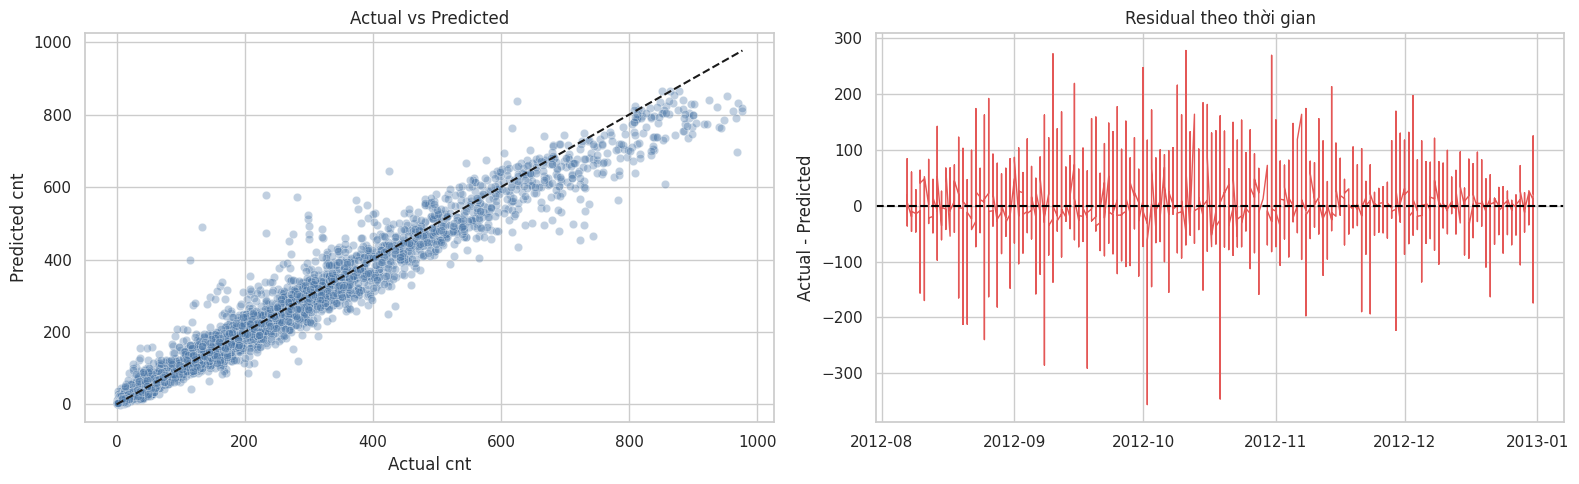

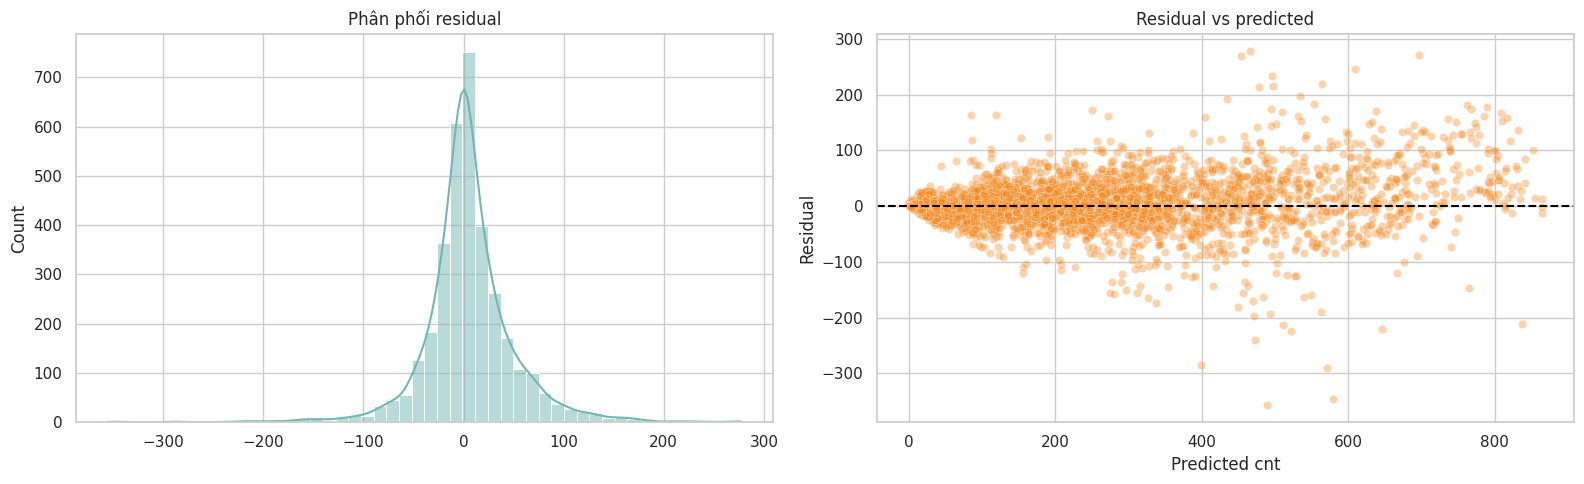

,feature,importance
23,cnt_lag_1,177.4396
15,hr_cos,28.0550
14,hr_sin,17.5742
22,rush_hour_workingday,16.4683
3,hr,13.9779
24,cnt_lag_24,10.4379
25,cnt_lag_168,10.3639
7,weathersit,4.1066
6,workingday,3.9845
8,temp,3.5251


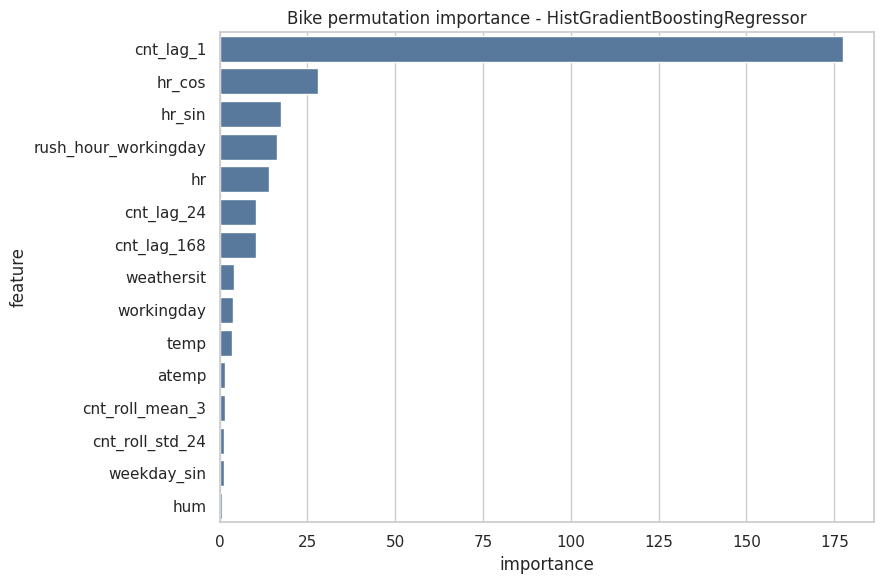

In [8]:
bike_pred = best_bike_model.predict(X_bike_test)
bike_holdout_metrics = pd.DataFrame([regression_metrics(y_bike_test, bike_pred)], index=[best_bike_name])
display(bike_holdout_metrics)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(x=y_bike_test, y=bike_pred, alpha=0.35, ax=ax[0], color='#4C78A8')
limit = max(float(y_bike_test.max()), float(np.max(bike_pred)))
ax[0].plot([0, limit], [0, limit], 'k--')
ax[0].set_title('Actual vs Predicted')
ax[0].set_xlabel('Actual cnt')
ax[0].set_ylabel('Predicted cnt')

bike_resid = y_bike_test.to_numpy() - bike_pred
ax[1].plot(bike_model_df.iloc[split_idx:]['dteday'], bike_resid, color='#E45756', linewidth=1)
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_title('Residual theo thời gian')
ax[1].set_ylabel('Actual - Predicted')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(bike_resid, bins=50, kde=True, ax=ax[0], color='#72B7B2')
ax[0].set_title('Phân phối residual')
sns.scatterplot(x=bike_pred, y=bike_resid, alpha=0.35, ax=ax[1], color='#F58518')
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_title('Residual vs predicted')
ax[1].set_xlabel('Predicted cnt')
ax[1].set_ylabel('Residual')
plt.tight_layout()
plt.show()

bike_importance = plot_perm_importance(
    best_bike_model,
    X_bike_test,
    y_bike_test,
    'neg_root_mean_squared_error',
    f'Bike permutation importance - {best_bike_name}',
)

### Output đánh giá Bike

Model cuối cùng đạt MAE khoảng `29.75`, RMSE khoảng `46.15` và R2 khoảng `0.9562` trên holdout. Với target `cnt` có mean khoảng `189.46`, sai số trung bình này cho thấy mô hình đã học được phần lớn cấu trúc nhu cầu theo giờ.

Permutation importance cho thấy các tín hiệu mạnh nhất là:

- `cnt_lag_1`: nhu cầu ngay giờ trước, quan trọng nhất với khoảng cách rất lớn.
- `hr_cos`, `hr_sin`, `hr`: chu kỳ giờ trong ngày.
- `rush_hour_workingday`: giờ cao điểm trong ngày làm việc.
- `cnt_lag_24`, `cnt_lag_168`: cùng giờ hôm trước và cùng giờ tuần trước.
- `weathersit`, `workingday`, `temp`, `atemp`, `hum`: điều kiện lịch/thời tiết bổ sung.


# 2. Telco Customer Churn Prediction

## 2.1. Tải dữ liệu và chuẩn hóa kiểu dữ liệu

Bài toán Telco khác Bike ở chỗ đây là phân loại nhị phân và dữ liệu không có thứ tự thời gian rõ trong notebook. Mục tiêu là dự đoán xác suất khách hàng churn, sau đó dùng xác suất này để xếp hạng rủi ro hoặc đưa ra nhãn theo một threshold phù hợp.

Cell này thực hiện các bước:

1. Tải dataset Kaggle `blastchar/telco-customer-churn`.
2. Chọn file `WA_Fn-UseC_-Telco-Customer-Churn.csv`.
3. Đọc dữ liệu vào `telco_df`.
4. Strip khoảng trắng ở tên cột để tránh lỗi truy cập column.
5. Chuyển `TotalCharges` sang numeric bằng `pd.to_numeric(..., errors='coerce')`.

`TotalCharges` trong dataset gốc thường được lưu như chuỗi vì có một số giá trị rỗng. Khi ép kiểu, các giá trị rỗng trở thành `NaN`. 


In [18]:
telco_root = download_dataset('blastchar/telco-customer-churn')
telco_csv = find_csv(telco_root, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Using:', telco_csv)

telco_df = pd.read_csv(telco_csv)
telco_df.columns = telco_df.columns.str.strip()
telco_df['TotalCharges'] = pd.to_numeric(telco_df['TotalCharges'], errors='coerce')
print('Shape:', telco_df.shape)
display(telco_df.head())
telco_df.info()

Downloaded blastchar/telco-customer-churn -> /kaggle/input/telco-customer-churn
 - WA_Fn-UseC_-Telco-Customer-Churn.csv
Using: /kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.8500,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,"1,889.5000",No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.1500,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,"1,840.7500",No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.6500,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Dữ liệu Telco có `7,043` khách hàng và `21` cột. Sau khi chuyển `TotalCharges` sang numeric, cột này có `7,032` giá trị non-null, tức còn `11` giá trị thiếu.

Một vài quan sát quan trọng từ output:

- Phần lớn biến là categorical: `Contract`, `PaymentMethod`, `InternetService`, các dịch vụ add-on và thông tin nhân khẩu.
- Numeric chính gồm `SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`; trong đó `SeniorCitizen` thực chất là biến nhị phân dạng category nên sẽ được map lại ở bước preprocessing.
- Target `Churn` đang ở dạng `Yes/No`, sẽ được chuyển thành `1/0` khi modeling.
- `customerID` là duy nhất cho từng khách hàng, không chứa quy luật có thể áp dụng cho khách hàng mới, nên phải loại khỏi feature.

Việc phát hiện `TotalCharges` missing ở bước này rất quan trọng. Nếu ép kiểu lỗi hoặc để cột này ở dạng object, pipeline numeric sẽ không xử lý đúng và mô hình có thể mất một tín hiệu tài chính quan trọng.


## 2.2. EDA Telco Churn

Mục tiêu EDA Telco là hiểu **nhóm khách hàng nào có rủi ro churn cao** và dữ liệu có vấn đề mất cân bằng/missing/leakage hay không. Với bài toán churn, EDA phải phục vụ hai quyết định chính:

1. Chọn metric phù hợp, vì accuracy dễ gây hiểu nhầm khi lớp churn ít.
2. Nhận diện các nhóm rủi ro để mô hình và kết luận kinh doanh có thể giải thích được.

Cell này tạo ra các bảng và biểu đồ sau.

## Nhóm kiểm tra dữ liệu

- `Rows, columns`: xác nhận số khách hàng và số biến.
- `Duplicate rows`: kiểm tra dòng trùng.
- `describe(include='all')`: xem phân phối numeric và tần suất categorical.
- `show_missing(telco_df)`: tìm cột có missing, đặc biệt là `TotalCharges`.
- `churn_distribution`: đo tỷ lệ churn/no-churn.
- Bảng missing `TotalCharges`: kiểm tra missing có liên quan tới khách hàng mới hay không.

## Nhóm bảng churn rate

- Churn rate theo `Contract`.
- Churn rate theo `PaymentMethod`.
- Churn rate theo `InternetService`.
- Churn rate theo `tenure_group`.
- Churn rate theo các dịch vụ add-on như `OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtection`.

Các bảng này giúp xác định biến nào có khả năng dự báo churn mạnh.

Rows, columns: (7043, 21)
Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,"7,043.0000",NaN,NaN,NaN,0.1621,0.3686,0.0000,0.0000,0.0000,0.0000,1.0000
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,"7,043.0000",NaN,NaN,NaN,32.3711,24.5595,0.0000,9.0000,29.0000,55.0000,72.0000
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_count,missing_rate
TotalCharges,11,0.0016
customerID,0,0.0000
gender,0,0.0000
SeniorCitizen,0,0.0000
Partner,0,0.0000
Dependents,0,0.0000
tenure,0,0.0000
PhoneService,0,0.0000
MultipleLines,0,0.0000
InternetService,0,0.0000


,count,rate
Churn,,
No,5174,0.7346
Yes,1869,0.2654


Rows with missing TotalCharges: 11


...

,churn_rate
Contract,
Month-to-month,0.4271
One year,0.1127
Two year,0.0283


,churn_rate
PaymentMethod,
Electronic check,0.4529
Mailed check,0.1911
Bank transfer (automatic),0.1671
Credit card (automatic),0.1524


,churn_rate
InternetService,
Fiber optic,0.4189
DSL,0.1896
No,0.0740


,churn_rate
tenure_group,
1-6,0.5333
7-12,0.3589
13-24,0.2871
25-48,0.2039
49-72,0.0951
0,0.0000


,level,churn_rate,feature
0,No,0.4177,OnlineSecurity
9,No,0.4164,TechSupport
3,No,0.3993,OnlineBackup
6,No,0.3913,DeviceProtection
15,No,0.3368,StreamingMovies
12,No,0.3352,StreamingTV
13,Yes,0.3007,StreamingTV
16,Yes,0.2994,StreamingMovies
20,Yes,0.2861,MultipleLines
18,Yes,0.2671,PhoneService


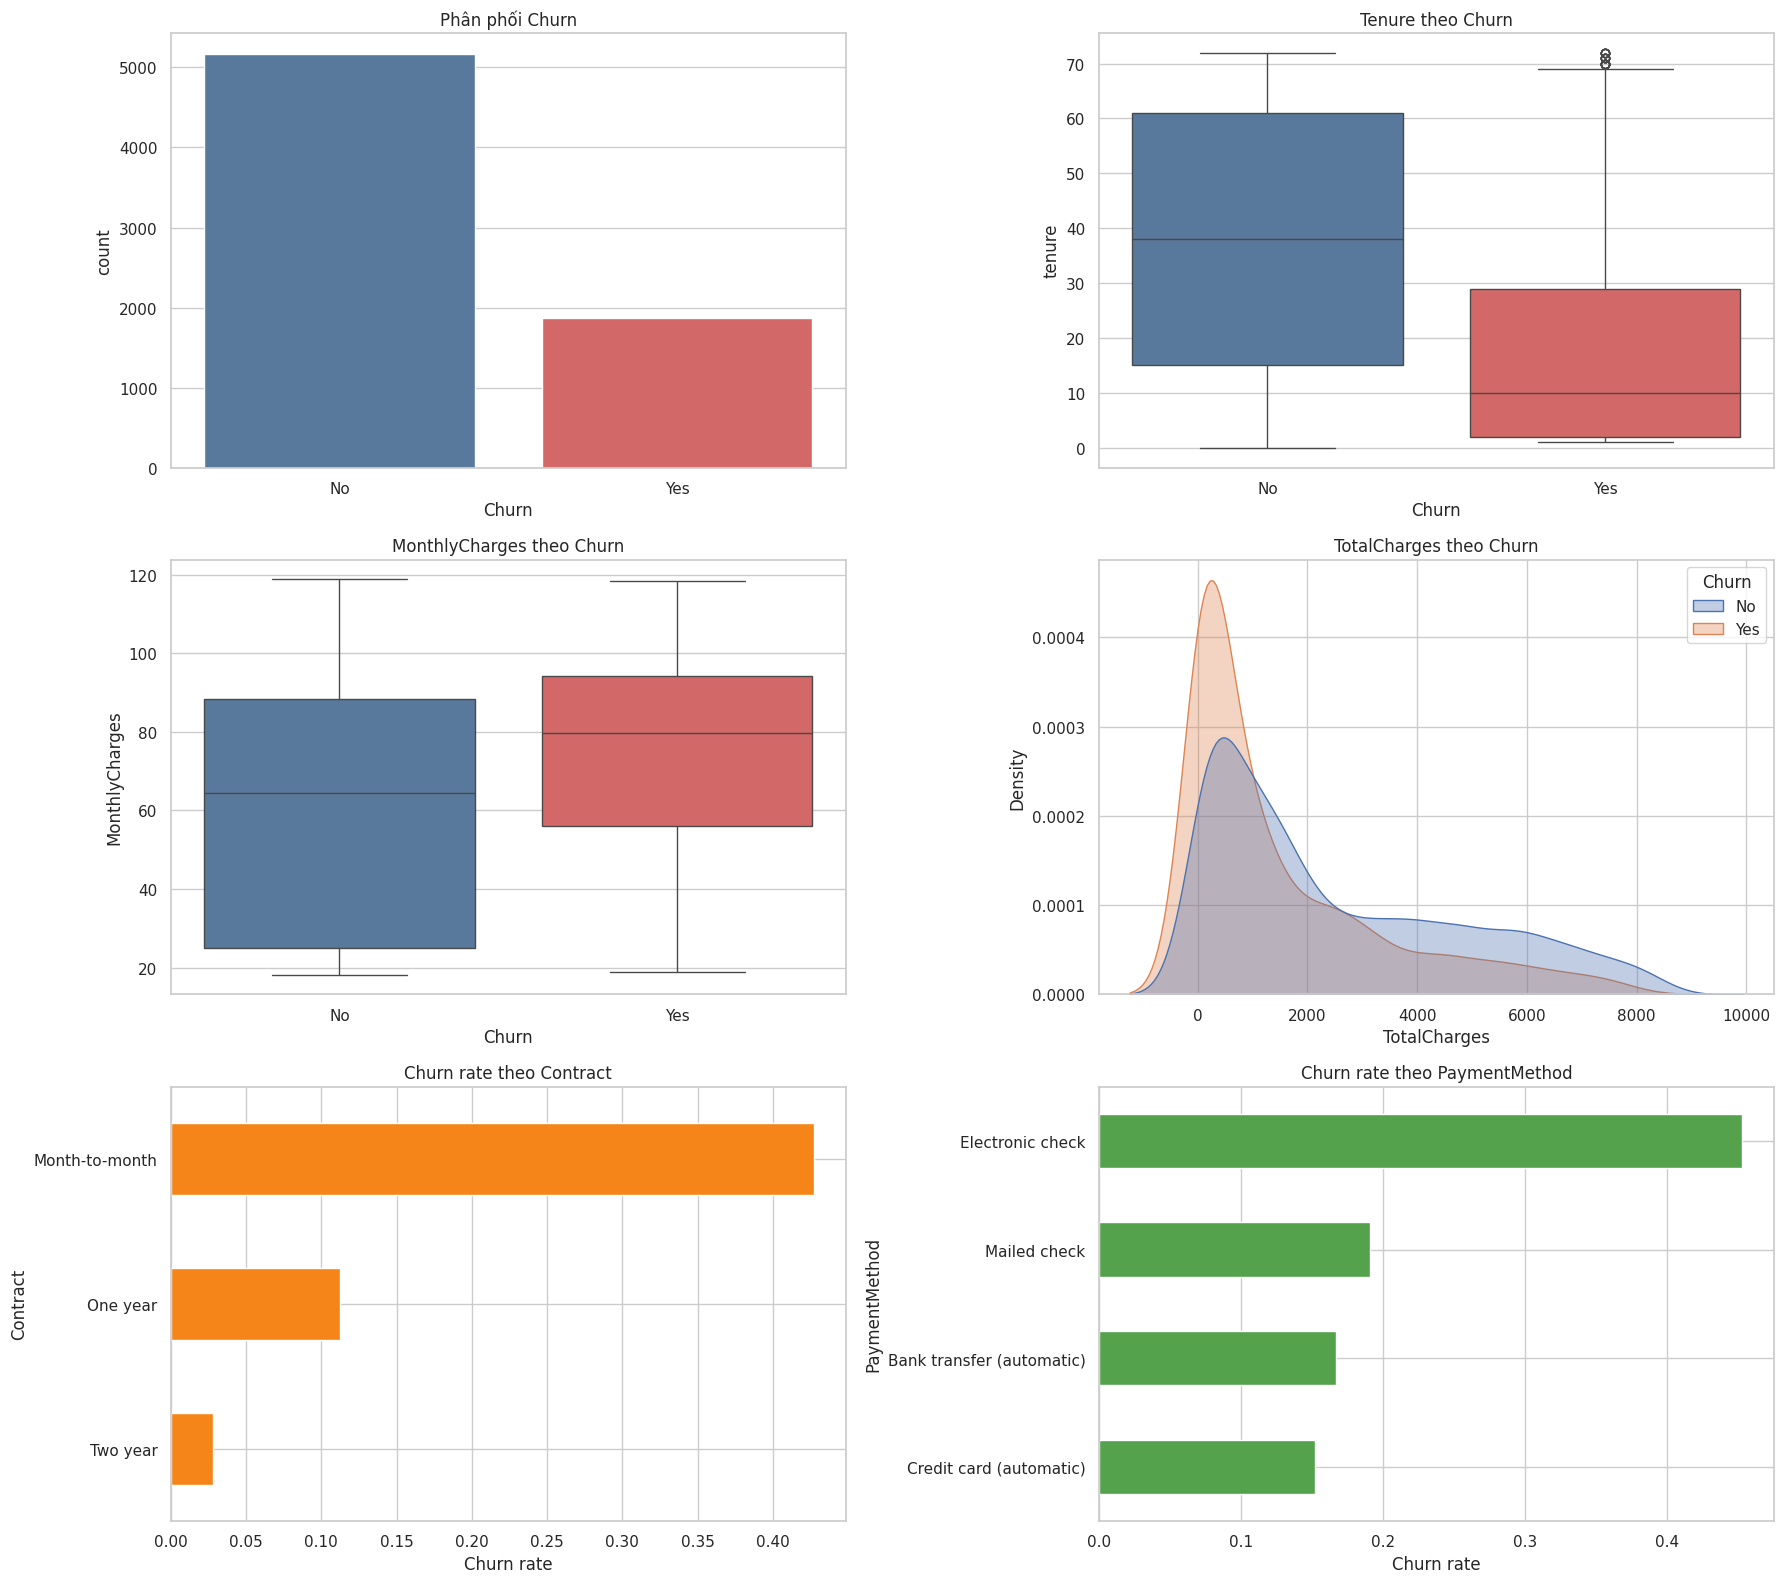

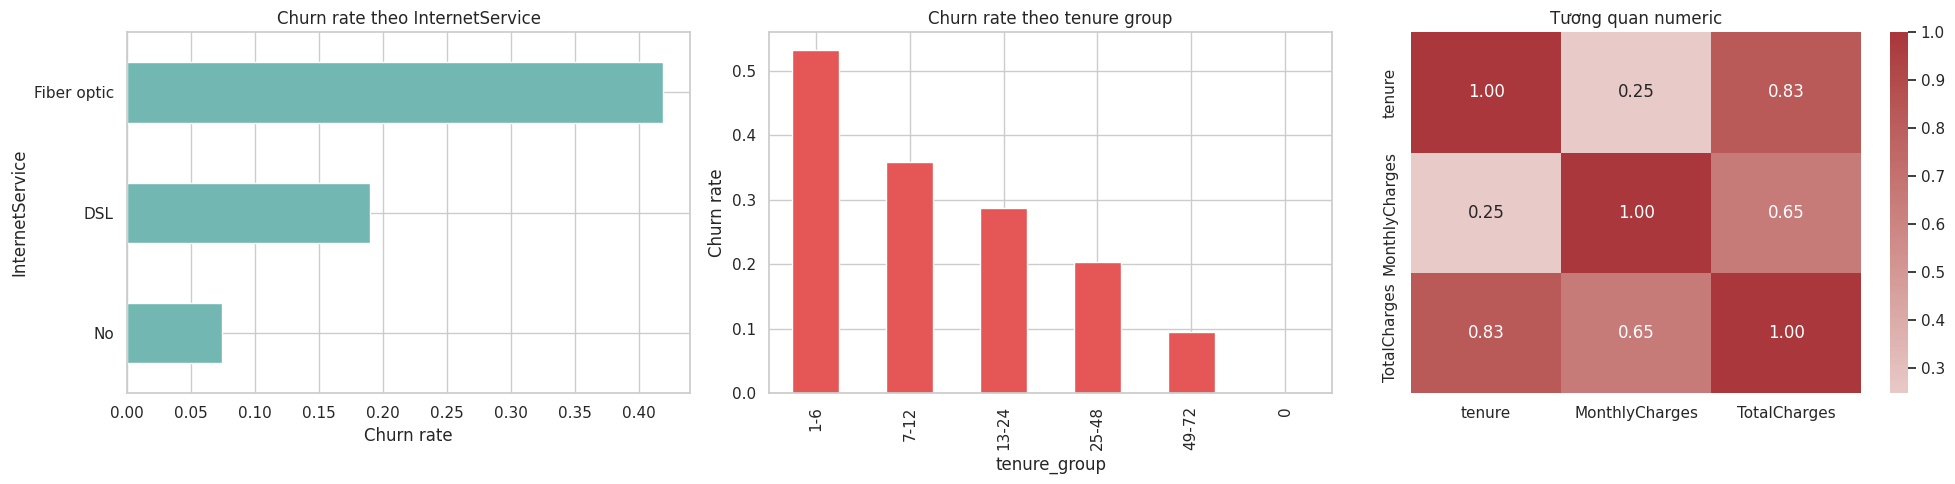

In [10]:
print('Rows, columns:', telco_df.shape)
print('Duplicate rows:', telco_df.duplicated().sum())
display(telco_df.describe(include='all').T)
display(show_missing(telco_df))

churn_distribution = telco_df['Churn'].value_counts().to_frame('count')
churn_distribution['rate'] = churn_distribution['count'] / len(telco_df)
display(churn_distribution)

missing_total_charges = telco_df.loc[telco_df['TotalCharges'].isna(), ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
print('Rows with missing TotalCharges:', len(missing_total_charges))
display(missing_total_charges.head(20))

telecom_numeric = ['tenure', 'MonthlyCharges', 'TotalCharges']
telco_df['tenure_group'] = pd.cut(
    telco_df['tenure'],
    bins=[-1, 0, 6, 12, 24, 48, 72],
    labels=['0', '1-6', '7-12', '13-24', '25-48', '49-72'],
)

def churn_rate_table(column):
    return (
        telco_df.groupby(column)['Churn']
        .apply(lambda s: (s == 'Yes').mean())
        .sort_values(ascending=False)
        .to_frame('churn_rate')
    )

for column in ['Contract', 'PaymentMethod', 'InternetService', 'tenure_group']:
    display(churn_rate_table(column))

service_columns = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PhoneService', 'MultipleLines'
]
service_churn = []
for column in service_columns:
    if column in telco_df.columns:
        rates = churn_rate_table(column).reset_index().rename(columns={column: 'level'})
        rates['feature'] = column
        service_churn.append(rates)
service_churn_df = pd.concat(service_churn, ignore_index=True)
display(service_churn_df.sort_values('churn_rate', ascending=False).head(20))

fig, ax = plt.subplots(3, 2, figsize=(18, 16))
sns.countplot(data=telco_df, x='Churn', ax=ax[0, 0], palette=['#4C78A8', '#E45756'])
ax[0, 0].set_title('Phân phối Churn')
sns.boxplot(data=telco_df, x='Churn', y='tenure', ax=ax[0, 1], palette=['#4C78A8', '#E45756'])
ax[0, 1].set_title('Tenure theo Churn')

sns.boxplot(data=telco_df, x='Churn', y='MonthlyCharges', ax=ax[1, 0], palette=['#4C78A8', '#E45756'])
ax[1, 0].set_title('MonthlyCharges theo Churn')
sns.kdeplot(data=telco_df, x='TotalCharges', hue='Churn', common_norm=False, fill=True, alpha=0.35, ax=ax[1, 1])
ax[1, 1].set_title('TotalCharges theo Churn')

churn_rate_table('Contract').sort_values('churn_rate').plot(kind='barh', ax=ax[2, 0], color='#F58518', legend=False)
ax[2, 0].set_title('Churn rate theo Contract')
ax[2, 0].set_xlabel('Churn rate')
churn_rate_table('PaymentMethod').sort_values('churn_rate').plot(kind='barh', ax=ax[2, 1], color='#54A24B', legend=False)
ax[2, 1].set_title('Churn rate theo PaymentMethod')
ax[2, 1].set_xlabel('Churn rate')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
churn_rate_table('InternetService').sort_values('churn_rate').plot(kind='barh', ax=ax[0], color='#72B7B2', legend=False)
ax[0].set_title('Churn rate theo InternetService')
ax[0].set_xlabel('Churn rate')
churn_rate_table('tenure_group').plot(kind='bar', ax=ax[1], color='#E45756', legend=False)
ax[1].set_title('Churn rate theo tenure group')
ax[1].set_ylabel('Churn rate')
sns.heatmap(telco_df[telecom_numeric].corr(), annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax[2])
ax[2].set_title('Tương quan numeric')
plt.tight_layout()
plt.show()

telco_df = telco_df.drop(columns=['tenure_group'])

### Diễn giải output và kết luận EDA Telco

Dataset Telco có `7,043` khách hàng, `0` duplicate. Tỷ lệ churn là khoảng `26.54%`, còn no-churn khoảng `73.46%`. Đây là bài toán mất cân bằng lớp: một model đoán toàn bộ `No churn` vẫn có accuracy khoảng 73%, nhưng recall churn bằng 0.

Kết luận metric từ EDA:

- Không nên dùng accuracy làm metric chính.
- Cần đọc ROC-AUC, PR-AUC, precision, recall và F1.
- Threshold mặc định 0.5 có thể không tối ưu cho mục tiêu giữ chân khách hàng.

## 1. Missing `TotalCharges`

`TotalCharges` thiếu `11` dòng và tất cả đều có `tenure = 0`. Đây nhiều khả năng là khách hàng mới chưa phát sinh tổng phí tích lũy.

Ý nghĩa:

- Không nên drop toàn bộ cột `TotalCharges` vì nó vẫn là tín hiệu tài chính quan trọng.
- Không nhất thiết drop 11 dòng vì tỷ lệ missing rất nhỏ và có thể xử lý bằng imputation.
- Imputation phải nằm trong pipeline sau split để tránh leakage.

## 2. Countplot phân phối Churn

Countplot cho thấy `No churn` chiếm đa số. Điều này giải thích vì sao baseline `DummyClassifier` có accuracy khá cao nhưng không có giá trị kinh doanh.

Ý nghĩa:

- Nếu doanh nghiệp quan tâm giữ chân khách hàng, false negative quan trọng hơn accuracy tổng thể.
- Model cần dự báo xác suất/ranking, sau đó chọn threshold theo mục tiêu kinh doanh.

## 3. Boxplot `tenure` theo Churn

Boxplot tenure cho thấy khách churn thường có thời gian gắn bó thấp hơn nhóm không churn. Điều này khớp với bảng `tenure_group`, trong đó nhóm `1-6` tháng có churn rate khoảng `53.33%`, cao nhất trong các nhóm tenure.

Ý nghĩa:

- Giai đoạn đầu vòng đời khách hàng là giai đoạn rủi ro cao.
- `tenure` là một feature rất quan trọng.
- Chiến dịch onboarding/chăm sóc sớm có thể có tác động lớn hơn chăm sóc dàn đều toàn bộ khách hàng.

## 4. Boxplot `MonthlyCharges` theo Churn

Boxplot `MonthlyCharges` cho thấy nhóm churn có xu hướng trả phí hàng tháng cao hơn. Điều này gợi ý rủi ro churn có thể liên quan đến cảm nhận “giá trị nhận được so với số tiền trả hàng tháng”.

Ý nghĩa:

- `MonthlyCharges` nên giữ trong mô hình.
- Cần đọc phí tháng cùng với loại dịch vụ, đặc biệt là `InternetService = Fiber optic`.
- Khi triển khai retention, nhóm monthly charge cao có thể cần offer khác nhóm phí thấp.

## 5. KDE `TotalCharges` theo Churn

KDE `TotalCharges` thường cho thấy khách không churn có phân phối trải dài hơn ở vùng tổng phí cao, vì họ ở lại lâu hơn. Nhóm churn tập trung nhiều ở vùng tổng phí thấp/trung bình do tenure ngắn.

Ý nghĩa:

- `TotalCharges` có tín hiệu, nhưng phần lớn tín hiệu có thể đến từ tenure.
- Không nên diễn giải `TotalCharges` độc lập mà phải đọc cùng `tenure` và `MonthlyCharges`.
- Heatmap correlation phía sau giúp kiểm tra mối quan hệ này.

## 6. Churn rate theo `Contract`

Bảng và barplot cho thấy `Month-to-month` churn khoảng `42.71%`, cao hơn rất nhiều so với `One year` khoảng `11.27%` và `Two year` khoảng `2.83%`.

Ý nghĩa:

- `Contract` là tín hiệu churn rất mạnh.
- Khách month-to-month ít ràng buộc hơn, nên rủi ro rời dịch vụ cao hơn.
- Đây là nhóm cần ưu tiên trong chiến dịch giữ chân hoặc chuyển đổi sang hợp đồng dài hơn.

## 7. Churn rate theo `PaymentMethod`

`Electronic check` có churn rate khoảng `45.29%`, cao hơn các phương thức thanh toán tự động như credit card hoặc bank transfer.

Ý nghĩa:

- Phương thức thanh toán không chỉ là thông tin vận hành; nó phân biệt rủi ro churn.
- Thanh toán tự động có thể đi kèm nhóm khách ổn định hơn.
- Trong mô hình, `PaymentMethod` nên được one-hot encode và giữ lại.

## 8. Churn rate theo `InternetService`

`Fiber optic` có churn rate khoảng `41.89%`, cao hơn DSL và nhóm không dùng internet service.

Ý nghĩa:

- Nhóm Fiber optic cần được phân tích sâu hơn: có thể liên quan tới giá cao, kỳ vọng chất lượng cao hơn, hoặc gói dịch vụ khác.
- Không nên kết luận Fiber optic “gây churn”; đây là tín hiệu dự báo cần đọc cùng `MonthlyCharges`, `Contract` và add-on service.

## 9. Churn rate theo `tenure_group`

Churn cao nhất ở nhóm `1-6` tháng, sau đó giảm dần khi tenure tăng. Nhóm `49-72` tháng có churn rate thấp hơn nhiều.

Ý nghĩa:

- Rủi ro churn giảm khi khách hàng đã gắn bó lâu.
- Onboarding, chăm sóc 3-6 tháng đầu và phát hiện sớm bất mãn là chiến lược quan trọng.
- Model có thể dùng để tạo danh sách khách hàng mới có rủi ro cao.

## 10. Service add-on churn table

Các nhóm không có `OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtection` có churn rate cao hơn nhóm có dịch vụ tương ứng. Nhóm `No internet service` thường có churn thấp hơn.

Ý nghĩa:

- Dịch vụ hỗ trợ/bảo mật có thể là tín hiệu về mức độ gắn kết của khách hàng.
- Khách thiếu các add-on quan trọng có thể dễ churn hơn.
- Các biến add-on nên được giữ trong mô hình, và có thể dùng để thiết kế offer giữ chân.

## 11. Correlation heatmap numeric

Heatmap numeric giúp đọc quan hệ giữa `tenure`, `MonthlyCharges`, `TotalCharges`. `TotalCharges` thường tương quan mạnh với `tenure` vì tổng phí tích lũy tăng theo thời gian sử dụng.

Ý nghĩa:

- Nếu `TotalCharges` quan trọng trong mô hình, cần nhớ nó có thể đang đại diện một phần cho tenure.
- Model tree/boosting có thể xử lý quan hệ tương tác tốt hơn mô hình tuyến tính đơn giản.
- Khi giải thích business, không nên nói “tổng phí cao làm giảm churn” một cách nhân quả; cần nói tổng phí cao thường đi cùng khách hàng lâu năm.

## Kết luận EDA Telco:

- Churn tập trung ở khách hàng mới, hợp đồng month-to-month, electronic check, fiber optic và thiếu một số dịch vụ hỗ trợ/bảo mật.
- Dataset mất cân bằng, nên accuracy không đủ.
- Modeling nên tập trung vào ranking rủi ro bằng ROC-AUC/PR-AUC và tuning threshold theo mục tiêu giữ chân.
- Các insight EDA khớp với permutation importance sau modeling: `Contract`, `tenure`, `InternetService`, `TotalCharges`, `MonthlyCharges`, `OnlineSecurity`, `TechSupport` là nhóm tín hiệu chính.


## 2.3. Preprocessing, stratified split và chống leakage cho Telco

Sau EDA, dữ liệu Telco được chuyển thành ma trận feature/target cho bài toán phân loại.

## Tạo target và feature

- `y_telco = 1` nếu `Churn = Yes`, ngược lại là `0`.
- `X_telco` loại `Churn` và `customerID`.
- `customerID` bị loại vì là định danh duy nhất; nếu giữ lại, one-hot encoding sẽ tạo ra hàng nghìn dummy hiếm và không giúp dự báo khách hàng mới.
- `SeniorCitizen` được map từ `0/1` sang `No/Yes` để xử lý như categorical. Đây là lựa chọn hợp lý vì giá trị 0/1 không nên được hiểu như đại lượng liên tục.

## Split dữ liệu

Notebook dùng `train_test_split(..., stratify=y_telco, random_state=RANDOM_STATE)`. `stratify` đảm bảo tỷ lệ churn trong train và test gần bằng nhau. Đây là bước quan trọng vì churn chỉ chiếm khoảng 26.5%; nếu split ngẫu nhiên không stratify, test set có thể lệch tỷ lệ churn và metric không ổn định.

## Preprocessing

- Numeric features: `tenure`, `MonthlyCharges`, `TotalCharges`.
- Categorical features: giới tính, senior, partner, dependents, service, contract, billing và payment method.
- Numeric pipeline: median imputation + scaling.
- Categorical pipeline: most-frequent imputation + one-hot encoding.
- Tất cả được gói trong `ColumnTransformer` và sẽ nằm bên trong model pipeline.

Điểm quan trọng về leakage: imputer, scaler và encoder không được fit trên toàn bộ dataset trước CV. Khi đặt trong `Pipeline`, scikit-learn fit chúng riêng trên từng train fold, sau đó transform validation fold. Đây là cách đánh giá đúng cho dữ liệu chưa thấy.


In [11]:
y_telco = (telco_df['Churn'] == 'Yes').astype(int)
X_telco = telco_df.drop(columns=['Churn', 'customerID'], errors='ignore').copy()
if 'SeniorCitizen' in X_telco.columns:
    X_telco['SeniorCitizen'] = X_telco['SeniorCitizen'].map({0: 'No', 1: 'Yes'}).astype('object')

telco_num = X_telco.select_dtypes(include='number').columns.tolist()
telco_cat = X_telco.select_dtypes(exclude='number').columns.tolist()
X_telco_train, X_telco_test, y_telco_train, y_telco_test = train_test_split(
    X_telco,
    y_telco,
    test_size=0.2,
    stratify=y_telco,
    random_state=RANDOM_STATE,
)

print('Train/test:', X_telco_train.shape, X_telco_test.shape)
print('Positive rate train/test:', y_telco_train.mean(), y_telco_test.mean())
print('Numeric features:', telco_num)
print('Categorical features:', telco_cat)

telco_preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), telco_num),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', make_ohe()),
    ]), telco_cat),
], sparse_threshold=0.0)

Train/test: (5634, 19) (1409, 19)
Positive rate train/test: 0.2653532126375577 0.2654364797728886
Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 2.4. Baseline, model comparison và hyperparameter tuning cho Telco

Với churn prediction, mục tiêu chính không chỉ là dự báo nhãn đúng/sai ở threshold 0.5. Trong thực tế, doanh nghiệp thường cần xếp hạng khách hàng theo rủi ro để chọn top nhóm cần chăm sóc.

## Baseline

`DummyClassifier(strategy='most_frequent')` luôn dự báo lớp phổ biến nhất, tức `No churn`. Baseline này thường có accuracy khá cao do mất cân bằng lớp, nhưng precision/recall/F1 cho churn sẽ rất kém. Đây là mốc để nhắc rằng accuracy không đủ cho bài toán churn.

## Các mô hình được benchmark

- `LogisticRegression`: mô hình tuyến tính, dễ diễn giải, là baseline mạnh cho dữ liệu one-hot categorical.
- `RandomForestClassifier`: ensemble cây, học được quan hệ phi tuyến và tương tác biến.
- `HistGradientBoostingClassifier`: gradient boosting, thường mạnh cho dữ liệu tabular và có khả năng học pattern phi tuyến tốt.

## Xử lý mất cân bằng lớp

Với các model hỗ trợ, search space có `class_weight=[None, 'balanced']`. `balanced` tăng trọng số cho lớp thiểu số churn để model chú ý hơn tới recall. Cell cũng kiểm tra môi trường hiện tại có hỗ trợ `class_weight` cho HGB hay không trước khi thêm tham số này.

## Cross-validation và metric selection

- `StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)` giữ tỷ lệ churn trong từng fold.
- `RandomizedSearchCV` thử 8 tổ hợp hyperparameter cho mỗi model.
- `scoring='roc_auc'` chọn model có khả năng xếp hạng churn tốt nhất.


In [12]:
telco_results = []
telco_best = {}

baseline_clf = Pipeline([
    ('preprocess', clone(telco_preprocess)),
    ('model', DummyClassifier(strategy='most_frequent')),
])
baseline_clf.fit(X_telco_train, y_telco_train)
baseline_score = baseline_clf.predict_proba(X_telco_test)[:, 1]
baseline_row = classification_metrics(y_telco_test, baseline_score, threshold=0.5)
baseline_row.update({'model': 'DummyClassifier', 'cv_roc_auc': np.nan, 'best_params': {}})
telco_results.append(baseline_row)

hgb_clf = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
hgb_space = {
    'learning_rate': loguniform(0.01, 0.2),
    'max_iter': [100, 200, 300],
    'max_leaf_nodes': [15, 31, 63],
    'min_samples_leaf': [10, 20, 50],
    'l2_regularization': loguniform(1e-4, 1.0),
}
if estimator_supports_parameter(hgb_clf, 'class_weight'):
    hgb_space['class_weight'] = [None, 'balanced']
    print('HistGradientBoostingClassifier supports class_weight; included in search space.')
else:
    print('HistGradientBoostingClassifier in this environment does not expose class_weight; class-weighted LogisticRegression and RandomForest remain in the comparison.')

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
telco_spaces = {
    'LogisticRegression': (
        LogisticRegression(max_iter=2000, solver='liblinear', random_state=RANDOM_STATE),
        {
            'C': loguniform(1e-3, 100),
            'class_weight': [None, 'balanced'],
        },
    ),
    'RandomForestClassifier': (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 5, 10, 20],
            'min_samples_leaf': [1, 2, 5, 10],
            'max_features': ['sqrt', 0.7, 1.0],
            'class_weight': [None, 'balanced'],
        },
    ),
    'HistGradientBoostingClassifier': (hgb_clf, hgb_space),
}

for name, (model, space) in telco_spaces.items():
    print('\nTuning', name)
    pipe = Pipeline([('preprocess', clone(telco_preprocess)), ('model', model)])
    search = RandomizedSearchCV(
        pipe,
        {f'model__{key}': value for key, value in space.items()},
        n_iter=8,
        scoring='roc_auc',
        cv=cv_clf,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )
    search.fit(X_telco_train, y_telco_train)
    score = search.predict_proba(X_telco_test)[:, 1]
    row = classification_metrics(y_telco_test, score, threshold=0.5)
    row.update({'model': name, 'cv_roc_auc': search.best_score_, 'best_params': search.best_params_})
    telco_results.append(row)
    telco_best[name] = search.best_estimator_

telco_results_df = pd.DataFrame(telco_results)
telco_display_df = telco_results_df.sort_values(['cv_roc_auc', 'roc_auc'], ascending=False, na_position='last')
display(telco_display_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc', 'cv_roc_auc', 'best_params']])

best_telco_name = telco_display_df.dropna(subset=['cv_roc_auc']).iloc[0]['model']
best_telco_model = telco_best[best_telco_name]
print('Best telco model selected by CV ROC-AUC:', best_telco_name)
display(pd.DataFrame([{
    'selected_model': best_telco_name,
    'selection_metric': 'StratifiedKFold cv_roc_auc',
    'best_params': telco_display_df.loc[telco_display_df['model'].eq(best_telco_name), 'best_params'].iloc[0],
}]))

HistGradientBoostingClassifier supports class_weight; included in search space.

Tuning LogisticRegression
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Tuning RandomForestClassifier
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Tuning HistGradientBoostingClassifier
Fitting 5 folds for each of 8 candidates, totalling 40 fits


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,cv_roc_auc,best_params
3,HistGradientBoostingClassifier,0.8020,0.6589,0.5267,0.5854,0.8469,0.6571,0.8479,"{'model__class_weight': None, 'model__l2_regul..."
2,RandomForestClassifier,0.8027,0.6702,0.5053,0.5762,0.8433,0.6550,0.8469,"{'model__n_estimators': 100, 'model__min_sampl..."
1,LogisticRegression,0.8055,0.6572,0.5588,0.6040,0.8419,0.6342,0.8461,"{'model__C': 0.9846738873614566, 'model__class..."
0,DummyClassifier,0.7346,0.0000,0.0000,0.0000,0.5000,0.2654,NaN,{}


Best telco model selected by CV ROC-AUC: HistGradientBoostingClassifier


,selected_model,selection_metric,best_params
0,HistGradientBoostingClassifier,StratifiedKFold cv_roc_auc,"{'model__class_weight': None, 'model__l2_regul..."


### Output tuning Telco

Kết quả chọn `HistGradientBoostingClassifier` vì có `cv_roc_auc` cao nhất, khoảng `0.8479`. Đây là quyết định hợp lý nếu mục tiêu là ranking rủi ro churn ổn định trên cross-validation.

So sánh nhanh trên holdout ở threshold 0.5:

- `DummyClassifier`: ROC-AUC `0.5`, recall churn `0`, không có giá trị phát hiện churn.
- `LogisticRegression`: accuracy khoảng `0.8055`, F1 khoảng `0.6040`, ROC-AUC khoảng `0.8419`.
- `RandomForestClassifier`: ROC-AUC khoảng `0.8433`, F1 khoảng `0.5762`.
- `HistGradientBoostingClassifier`: ROC-AUC khoảng `0.8469`, PR-AUC khoảng `0.6571`, F1 khoảng `0.5854` ở threshold 0.5.


## 2.5. Đánh giá cuối Telco và threshold tuning

Sau khi chọn model bằng CV ROC-AUC, notebook chuyển sang câu hỏi triển khai: nên dùng threshold nào để biến xác suất churn thành nhãn `Churn`?

## Vì sao không mặc định threshold 0.5?

Trong churn prediction, chi phí hai loại lỗi thường không bằng nhau:

- False negative: khách hàng sẽ churn nhưng model bỏ sót. Doanh nghiệp mất cơ hội giữ chân.
- False positive: khách hàng không churn nhưng bị liên hệ/ưu đãi nhầm. Doanh nghiệp tốn chi phí chăm sóc.

Nếu bỏ sót churn đắt hơn liên hệ nhầm, threshold nên thấp hơn 0.5 để tăng recall.

## Cách threshold được chọn

Cell này dùng `cross_val_predict` trên `X_telco_train`, `y_telco_train` để tạo out-of-fold probability. OOF nghĩa là mỗi điểm train được dự báo bởi model không fit trên chính điểm đó. Sau đó:

1. Tính precision-recall curve trên OOF score.
2. Tính F1 tại các threshold.
3. Chọn threshold có F1 cao nhất trên OOF train.
4. Áp dụng threshold cố định đó lên test set.

Cách này đúng hơn việc chọn threshold trực tiếp trên test, vì test vẫn giữ vai trò đánh giá cuối.


Threshold tối ưu F1 từ train OOF: 0.3274404361629657


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
threshold_0.5,0.5000,0.8020,0.6589,0.5267,0.5854,0.8469,0.6571
threshold_tuned,0.3274,0.7771,0.5605,0.7433,0.6391,0.8469,0.6571



Classification report - threshold 0.5
              precision    recall  f1-score   support

    No churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Classification report - threshold tuned
              precision    recall  f1-score   support

    No churn       0.89      0.79      0.84      1035
       Churn       0.56      0.74      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409



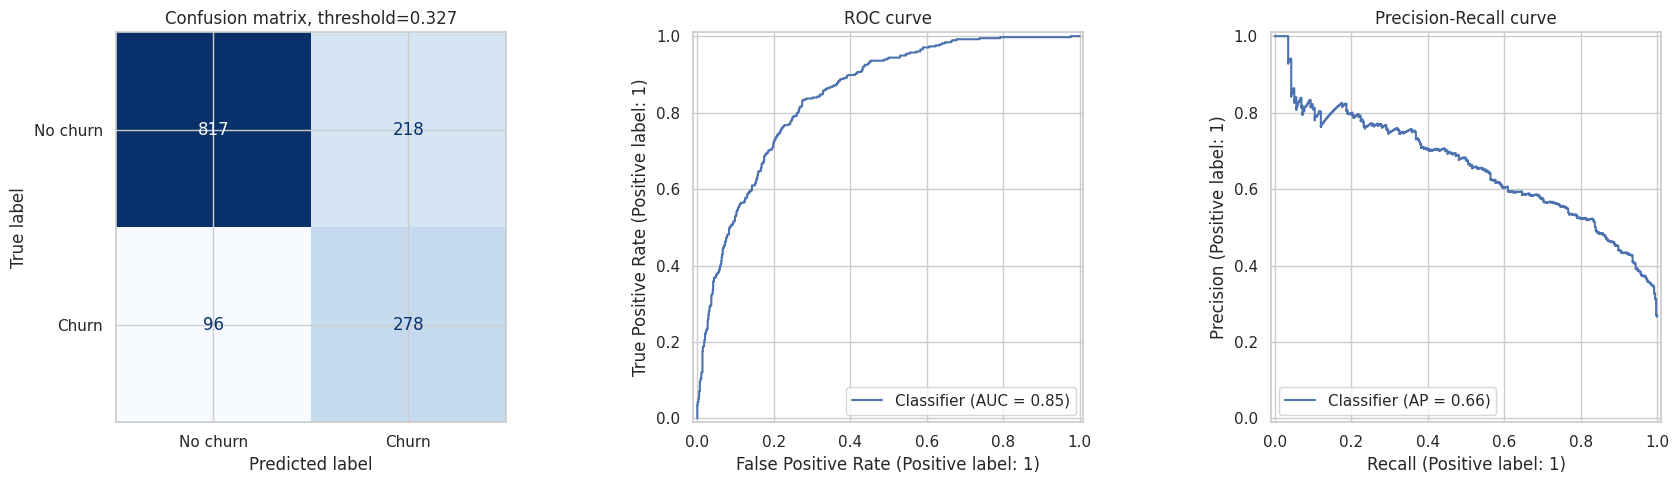

,feature,importance
14,Contract,0.1237
4,tenure,0.0438
7,InternetService,0.0122
18,TotalCharges,0.0068
17,MonthlyCharges,0.0067
8,OnlineSecurity,0.0051
11,TechSupport,0.0038
13,StreamingMovies,0.0027
6,MultipleLines,0.0026
16,PaymentMethod,0.0017


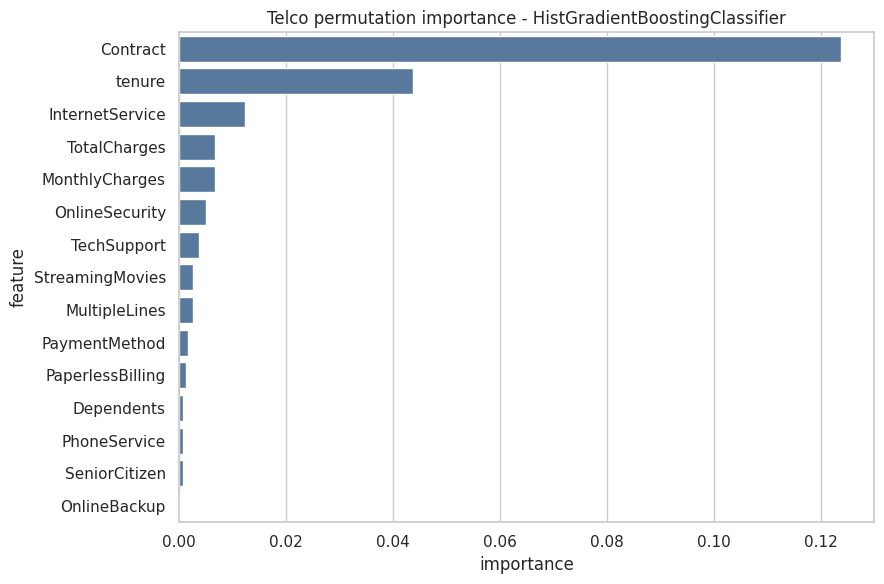

In [13]:
telco_score = best_telco_model.predict_proba(X_telco_test)[:, 1]

oof_score = cross_val_predict(
    best_telco_model,
    X_telco_train,
    y_telco_train,
    cv=cv_clf,
    method='predict_proba',
    n_jobs=-1,
)[:, 1]

prec, rec, thr = precision_recall_curve(y_telco_train, oof_score)
f1_curve = 2 * prec * rec / (prec + rec + 1e-12)
if len(thr) == 0:
    best_thr = 0.5
else:
    best_thr = float(thr[int(np.nanargmax(f1_curve[:-1]))])
print('Threshold tối ưu F1 từ train OOF:', best_thr)

metrics_05 = classification_metrics(y_telco_test, telco_score, threshold=0.5)
metrics_tuned = classification_metrics(y_telco_test, telco_score, threshold=best_thr)
threshold_results = pd.DataFrame([metrics_05, metrics_tuned], index=['threshold_0.5', 'threshold_tuned'])
display(threshold_results)

for label, threshold in [('0.5', 0.5), ('tuned', best_thr)]:
    print('\nClassification report - threshold', label)
    print(classification_report(
        y_telco_test,
        (telco_score >= threshold).astype(int),
        target_names=['No churn', 'Churn'],
        zero_division=0,
    ))

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(
    y_telco_test,
    (telco_score >= best_thr).astype(int),
    display_labels=['No churn', 'Churn'],
    cmap='Blues',
    colorbar=False,
    ax=ax[0],
)
ax[0].set_title(f'Confusion matrix, threshold={best_thr:.3f}')
RocCurveDisplay.from_predictions(y_telco_test, telco_score, ax=ax[1])
ax[1].set_title('ROC curve')
PrecisionRecallDisplay.from_predictions(y_telco_test, telco_score, ax=ax[2])
ax[2].set_title('Precision-Recall curve')
plt.tight_layout()
plt.show()

telco_importance = plot_perm_importance(
    best_telco_model,
    X_telco_test,
    y_telco_test,
    'roc_auc',
    f'Telco permutation importance - {best_telco_name}',
)

### Output threshold và evaluation Telco

Threshold tối ưu F1 từ OOF train là khoảng `0.3274`, thấp hơn threshold mặc định `0.5`. Điều này phù hợp với bài toán churn mất cân bằng: để bắt được nhiều khách hàng churn hơn, model cần gắn nhãn churn ở mức xác suất thấp hơn 50%.

So sánh trên test:

- Threshold `0.5`: accuracy `0.8020`, precision churn `0.6589`, recall churn `0.5267`, F1 `0.5854`.
- Threshold tuned `0.3274`: accuracy `0.7771`, precision churn `0.5605`, recall churn `0.7433`, F1 `0.6391`.

Đánh đổi:

- Recall tăng mạnh từ khoảng `52.67%` lên `74.33%`, nghĩa là model bắt được nhiều khách hàng churn hơn.
- Precision giảm từ khoảng `65.89%` xuống `56.05%`, nghĩa là trong nhóm bị gắn nhãn churn sẽ có nhiều false positive hơn.
- Accuracy giảm vì model dự báo churn nhiều hơn, nhưng F1 tăng vì cân bằng precision/recall cho lớp churn tốt hơn.
- ROC-AUC và PR-AUC không đổi khi đổi threshold, vì hai metric này đo ranking của score chứ không đo nhãn sau threshold.

Classification report cho thấy tại threshold tuned, lớp `Churn` có recall tốt hơn rõ rệt. Đây thường là lựa chọn phù hợp nếu mục tiêu kinh doanh là giảm bỏ sót khách hàng có nguy cơ rời dịch vụ.

Permutation importance cho thấy `Contract` là feature quan trọng nhất, tiếp theo là `tenure`, `InternetService`, `TotalCharges`, `MonthlyCharges`, `OnlineSecurity` và `TechSupport`. Kết quả này khớp với EDA: hợp đồng ngắn hạn, tenure thấp và thiếu dịch vụ hỗ trợ/bảo mật là các tín hiệu rủi ro churn mạnh.


### Tổng kết cho Telco

Pipeline Telco xử lý đúng các điểm cốt lõi của một bài toán churn:

1. Chuẩn hóa target `Yes/No` thành nhị phân.
2. Loại định danh `customerID` để tránh học thuộc từng khách hàng.
3. Giữ tỷ lệ churn bằng stratified split.
4. Đưa imputation, scaling và one-hot encoding vào pipeline để tránh leakage.
5. Chọn model bằng ROC-AUC CV vì mục tiêu chính là ranking rủi ro.
6. Tune threshold bằng OOF prediction từ train, không dùng test để chọn threshold.
7. Đọc kết quả bằng precision, recall, F1, ROC-AUC, PR-AUC và confusion matrix.

Kết luận từ EDA và modeling:

- EDA cho thấy `Contract`, `tenure`, `InternetService`, `MonthlyCharges`, `TotalCharges` và các add-on service liên quan mạnh tới churn.
- Permutation importance sau modeling cũng xếp `Contract`, `tenure`, `InternetService`, `TotalCharges`, `MonthlyCharges`, `OnlineSecurity`, `TechSupport` ở nhóm đầu.
- Điều này làm kết quả mô hình đáng tin hơn vì model không chỉ đạt metric tốt mà còn học những pattern có thể giải thích bằng nghiệp vụ.

Kết quả sau threshold tuning phù hợp hơn với mục tiêu giữ chân khách hàng: recall churn tăng mạnh, nghĩa là ít bỏ sót khách hàng có rủi ro hơn. Đổi lại, precision giảm, tức doanh nghiệp sẽ liên hệ nhầm nhiều khách hàng hơn.
